In [ ]:
# old final preprocessing
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

nltk.download('stopwords')
nltk.download('punkt')

# --- Configurations & Maps (From your code) ---
MONTH_MAP = {
    'jan': '01', 'january': '01', 'feb': '02', 'february': '02',
    'mar': '03', 'march': '03', 'apr': '04', 'april': '04',
    'may': '05', 'jun': '06', 'june': '06',
    'jul': '07', 'july': '07', 'aug': '08', 'august': '08',
    'sep': '09', 'september': '09', 'oct': '10', 'october': '10',
    'nov': '11', 'november': '11', 'dec': '12', 'december': '12'
}

WRITTEN_NUMS = {
    re.compile(r'\bone\b', re.I): '1', re.compile(r'\btwo\b', re.I): '2',
    re.compile(r'\bthree\b', re.I): '3', re.compile(r'\bfour\b', re.I): '4',
    re.compile(r'\bfive\b', re.I): '5', re.compile(r'\bsix\b', re.I): '6',
    re.compile(r'\bseven\b', re.I): '7', re.compile(r'\beight\b', re.I): '8',
    re.compile(r'\bnine\b', re.I): '9', re.compile(r'\bten\b', re.I): '10'
}

FINANCIAL_NOISE_STOPWORDS = {
    # Punctuation/Noise
    '-', "''", "'",
    # Numbers & Timeline metadata
    '2009', '2008', '2007', '2006', '2010', '2005', '1', '2',
    'year', 'period', 'quarter', 'today', 'first', 'end',
    # Entities & Locations
    'finnish', 'finland', 'helsinki', 'hel', 'nokia',
    # Corporate Boilerplate
    'oyj', 'oy', 'corpor', 'omx', 'group', 'compani',
    # Generic Verbs & English Stop Words
    'said', 'also', 'includ', 'accord', 'use', 'well',
    'per', 'part', 'would', 'base', 'provid'
}

PRESERVED_WORDS = {
    'good', 'bad', 'high', 'low', 'risk', 'profit', 'loss',
    'up', 'down', 'increase', 'decrease', 'increas', 'decreas',
    'strong', 'weak', 'better', 'worse', 'positive', 'negative',
    'stable', 'volatile', 'only', 'below', 'few', 'more',
    'no', 'not', 'nor', 'over', 'should', 'but'
}

english_defaults = set(stopwords.words('english'))

CUSTOM_STOPWORDS = (english_defaults | FINANCIAL_NOISE_STOPWORDS) - PRESERVED_WORDS

STANDARD_STOPWORDS = set(stopwords.words('english'))
stemmer = PorterStemmer()

PHONE_NUMBER = re.compile(r"(?<!\w)\+[\d\s\-\(\)]{6,20}(?!\w)")
STOCK_TICKER = re.compile(r"\([A-Z]+(\s*:\s*[A-Z0-9]+)?\)")
PHONE_PLACEHOLDER = "__PHONE__"

DATE_RANGE_WITH_YEAR = re.compile(r"\b([a-zA-Z]+)\s+(\d{1,2})\s*-\s*([a-zA-Z]+)\s+(\d{1,2})\s*,?\s*(\d{4})\b", re.I)
MONTH_MONTH_YEAR = re.compile(r"\b([a-zA-Z]+)-([a-zA-Z]+)\s+(\d{4})\b", re.I)
MONTH_MONTH = re.compile(r"\b([a-zA-Z]+)-([a-zA-Z]+)\b", re.I)
DAY_MONTH_YEAR = re.compile(r"\b(\d{1,2})\s+([a-zA-Z]+)\s+(\d{4})\b", re.I)
MONTH_DAY_YEAR = re.compile(r"\b([a-zA-Z]+)\s+(\d{1,2})[,\s]+(\d{4})\b", re.I)
MONTH_YEAR = re.compile(r"\b([a-zA-Z]+)\s+(\d{4})\b", re.I)
YEAR_MONTH = re.compile(r"\b(\d{4})\s+([a-zA-Z]+)\b", re.I)

EARLY_CLEANUP = [
    (re.compile(r"(x[0-9a-fA-F]{4}|[^\x00-\x7F]+)"), " "),
    (re.compile(r"(\d+)(st|nd|rd|th)", re.I), r"\1"),
    (re.compile(r"(\d)\s(\d)"), r"\1\2"),
    (re.compile(r"(\.)\s(\d)"), r"\1\2"),
    (re.compile(r"(\d)\s(\.)"), r"\1\2"),
]

FINANCIAL_CLEANUP = [
    (re.compile(r"x20ac"), "eur"),
    (re.compile(r"\$"), "usd"),
    (re.compile(r"\%"), "pct"),
    (re.compile(r"(\d+\.?\d*)\s*(percent|per cent)"), r"\1pct"),
    (re.compile(r"\b(euros?|SEK|sek)\b", re.I), "eur"),
    (re.compile(r"\bmln\b", re.I), "mn"),
    (re.compile(r"\b(\d+\.?\d*)\s*billion\b", re.I), r"\1bn"),
    (re.compile(r"\b(\d+\.?\d*)\s*million\b", re.I), r"\1mn"),
    (re.compile(r"(eur|usd|gbp|jpy|chf|sek)\s*([-+]?\d+\.?\d*)\s*(m|mn|bn|k|pct|%)", re.I), r"\1\2\3"),
    (re.compile(r"([-+]?\d+\.?\d*)\s*(m|mn|bn|k|pct|%)", re.I), r"\1\2"),
    (re.compile(r"(eur|usd|gbp|jpy|chf|sek)\s*([-+]?\d+\.?\d*)", re.I), r"\1\2"),
    (re.compile(r"([-+]?\d+\.?\d*)\s*(eur|usd|gbp|jpy|chf|sek|gmt)(?!\d)", re.I), r"\2\1"),
    (re.compile(r"(\d+\.?\d*)\s*(m|mn|bn|k|pct)\s*(eur|usd|gbp|jpy|chf|sek)", re.I), r"\3\1\2"),
    (re.compile(r"(eur|usd|gbp|jpy|chf|sek)(\d+)\s*,\s*(\d+)\s*(m|mn|bn|k)", re.I), r"\1\2,\3\4"),
    (re.compile(r"(\d+)(pct|mn|bn|k|%)\s*-\s*(\d+)\2", re.I), r"\1-\3\2"),
    (re.compile(r"(\d+),(\d+)"), r"\1.\2"),
]

LATE_CLEANUP = [
    (re.compile(r"(\d{1,2}:\d{2})\s*(am|pm)\b", re.I), r"\1\2"),
    (re.compile(r"\bsq\s*m\b", re.I), "sqm"),
    (re.compile(r"(\d+)\s*(sqm|m|km|kg|g)", re.I), r"\1\2"),
    (re.compile(r"\b([a-zA-Z]+)\s*(\d{1,2})\s*-\s*([a-zA-Z]+)\s*(\d{1,2})\b"), r"\1\2-\3\4"),
    (re.compile(r"(?<!\d)(\d{4})-(\d{2})(?!\d)"), r"\1-20\2"),
    (re.compile(r"\b(\d{1,2})-(\d{4})\b"), lambda m: f"{m.group(2)}-{m.group(1).zfill(2)}"),
    (re.compile(r"(?<!\d)[^\w\s'=%-]|[^\w\s'=%-](?!\d)"), ""),
    (re.compile(r"\s+"), " "),
    (re.compile(r"\s*'(\w+)"), ""),
]

def normalize_dates_smart(text):
    def repl_range_year(m):
        m1, m2 = m.group(1).lower(), m.group(3).lower()
        if m1 in MONTH_MAP and m2 in MONTH_MAP:
            return f"{m.group(5)}-{MONTH_MAP[m1]}-{m.group(2).zfill(2)} to {m.group(5)}-{MONTH_MAP[m2]}-{m.group(4).zfill(2)}"
        return m.group(0)
    text = DATE_RANGE_WITH_YEAR.sub(repl_range_year, text)

    def repl_mo_mo_yr(m):
        m1, m2 = m.group(1).lower(), m.group(2).lower()
        if m1 in MONTH_MAP and m2 in MONTH_MAP:
            return f"{m.group(3)}-{MONTH_MAP[m1]}-{MONTH_MAP[m2]}"
        return m.group(0)
    text = MONTH_MONTH_YEAR.sub(repl_mo_mo_yr, text)

    def repl_mo_mo(m):
        m1, m2 = m.group(1).lower(), m.group(2).lower()
        if m1 in MONTH_MAP and m2 in MONTH_MAP:
            return f"{MONTH_MAP[m1]}-{MONTH_MAP[m2]}"
        return m.group(0)
    text = MONTH_MONTH.sub(repl_mo_mo, text)

    def repl_d_m_y(m):
        mo = m.group(2).lower()
        if mo in MONTH_MAP:
            return f"{m.group(3)}-{MONTH_MAP[mo]}-{m.group(1).zfill(2)}"
        return m.group(0)
    text = DAY_MONTH_YEAR.sub(repl_d_m_y, text)

    def repl_m_d_y(m):
        mo = m.group(1).lower()
        if mo in MONTH_MAP:
            return f"{m.group(3)}-{MONTH_MAP[mo]}-{m.group(2).zfill(2)}"
        return m.group(0)
    text = MONTH_DAY_YEAR.sub(repl_m_d_y, text)

    def repl_m_y(m):
        mo = m.group(1).lower()
        if mo in MONTH_MAP:
            return f"{m.group(2)}-{MONTH_MAP[mo]}"
        return m.group(0)
    text = MONTH_YEAR.sub(repl_m_y, text)

    def repl_y_m(m):
        mo = m.group(2).lower()
        if mo in MONTH_MAP:
            return f"{m.group(1)}-{MONTH_MAP[mo]}"
        return m.group(0)
    text = YEAR_MONTH.sub(repl_y_m, text)

    return text

# --- Strategy 1: Full Preprocessing ---
def preprocess_full(text):
    if not isinstance(text, str): return ""
    text = text.lower()
    phones = re.findall(PHONE_NUMBER, text)
    text = PHONE_NUMBER.sub(PHONE_PLACEHOLDER, text)
    text = STOCK_TICKER.sub(lambda m: m.group(0).replace(" ", ""), text)

    for reg, repl in EARLY_CLEANUP: text = reg.sub(repl, text)
    for word_regex, num in WRITTEN_NUMS.items(): text = word_regex.sub(num, text)

    text = normalize_dates_smart(text)
    text = re.sub(r"(?<=\d),(?=\d)", "", text)

    for reg, repl in (FINANCIAL_CLEANUP + LATE_CLEANUP): text = reg.sub(repl, text)
    for p in phones: text = text.replace(PHONE_PLACEHOLDER, p.replace(" ", ""), 1)

    tokens = [word for word in text.split() if word not in CUSTOM_STOPWORDS]
    stemmed_tokens = [stemmer.stem(word) for word in tokens]
    return " ".join(stemmed_tokens).strip()

# --- Strategy 2: Full Preprocessing + Masking ---
def preprocess_masked(text):
    # First, run the full strategy
    text = preprocess_full(text)

    # Then apply the specific semantic masks before returning
    text = re.sub(r'\b[a-z]{3}\d+\.?\d*[a-z]{1,2}\b', ' [MONEY_METRIC] ', text)
    text = re.sub(r'\b\d{4}-\d{2}-\d{2}\b', ' [DATE_MARKER] ', text)
    text = re.sub(r'\b\d{4}-\d{2}\b', ' [DATE_MARKER] ', text)
    text = re.sub(r'\b(19\d{2}|20\d{2})\b', ' [DATE_MARKER] ', text)
    text = re.sub(r'\b\d+\.?\d*pct\b', ' [PERCENT_METRIC] ', text)

    # Clean up extra spaces
    return re.sub(r'\s+', ' ', text).strip()

# --- Strategy 3: Standard / Simple Preprocessing ---
def preprocess_standard(text):
    if not isinstance(text, str): return ""
    text = text.lower()
    # Basic punctuation removal
    text = re.sub(r'[^\w\s]', ' ', text)
    tokens = text.split()
    # Standard NLTK stopwords (loses words like "up", "down", "no")
    filtered = [word for word in tokens if word not in STANDARD_STOPWORDS]
    stemmed = [stemmer.stem(word) for word in filtered]
    return " ".join(stemmed).strip()


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/fabianhensel/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/fabianhensel/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [1]:
# current final preprocessing

import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

nltk.download('stopwords')
nltk.download('punkt')

# --- Configurations & Maps ---
MONTH_MAP = {
    'jan': '01', 'january': '01', 'feb': '02', 'february': '02',
    'mar': '03', 'march': '03', 'apr': '04', 'april': '04',
    'may': '05', 'jun': '06', 'june': '06',
    'jul': '07', 'july': '07', 'aug': '08', 'august': '08',
    'sep': '09', 'september': '09', 'oct': '10', 'october': '10',
    'nov': '11', 'november': '11', 'dec': '12', 'december': '12'
}

WRITTEN_NUMS = {
    re.compile(r'\bone\b', re.I): '1', re.compile(r'\btwo\b', re.I): '2',
    re.compile(r'\bthree\b', re.I): '3', re.compile(r'\bfour\b', re.I): '4',
    re.compile(r'\bfive\b', re.I): '5', re.compile(r'\bsix\b', re.I): '6',
    re.compile(r'\bseven\b', re.I): '7', re.compile(r'\beight\b', re.I): '8',
    re.compile(r'\bnine\b', re.I): '9', re.compile(r'\bten\b', re.I): '10'
}

FINANCIAL_NOISE_STOPWORDS = {
    # Punctuation/Noise
    '-', "''", "'",
    # Numbers & Timeline metadata
    '2009', '2008', '2007', '2006', '2010', '2005', '1', '2',
    'year', 'period', 'quarter', 'today', 'first', 'end',
    # Entities & Locations
    'finnish', 'finland', 'helsinki', 'hel', 'nokia',
    # Corporate Boilerplate
    'oyj', 'oy', 'corpor', 'omx', 'group', 'compani',
    # Generic Verbs & English Stop Words
    'said', 'also', 'includ', 'accord', 'use', 'well',
    'per', 'part', 'would', 'base', 'provid'
}

PRESERVED_WORDS = {
    'good', 'bad', 'high', 'low', 'risk', 'profit', 'loss',
    'up', 'down', 'increase', 'decrease', 'increas', 'decreas',
    'strong', 'weak', 'better', 'worse', 'positive', 'negative',
    'stable', 'volatile', 'only', 'below', 'few', 'more',
    'no', 'not', 'nor', 'over', 'should', 'but'
}

english_defaults = set(stopwords.words('english'))

CUSTOM_STOPWORDS = (english_defaults | FINANCIAL_NOISE_STOPWORDS) - PRESERVED_WORDS

stemmer = PorterStemmer()

PHONE_NUMBER = re.compile(r"(?<!\w)\+[\d\s\-\(\)]{6,20}(?!\w)")
STOCK_TICKER = re.compile(r"\([A-Z]+(\s*:\s*[A-Z0-9]+)?\)")
PHONE_PLACEHOLDER = "__PHONE__"

DATE_RANGE_WITH_YEAR = re.compile(r"\b([a-zA-Z]+)\s+(\d{1,2})\s*-\s*([a-zA-Z]+)\s+(\d{1,2})\s*,?\s*(\d{4})\b", re.I)
MONTH_MONTH_YEAR = re.compile(r"\b([a-zA-Z]+)-([a-zA-Z]+)\s+(\d{4})\b", re.I)
MONTH_MONTH = re.compile(r"\b([a-zA-Z]+)-([a-zA-Z]+)\b", re.I)
DAY_MONTH_YEAR = re.compile(r"\b(\d{1,2})\s+([a-zA-Z]+)\s+(\d{4})\b", re.I)
MONTH_DAY_YEAR = re.compile(r"\b([a-zA-Z]+)\s+(\d{1,2})[,\s]+(\d{4})\b", re.I)
MONTH_YEAR = re.compile(r"\b([a-zA-Z]+)\s+(\d{4})\b", re.I)
YEAR_MONTH = re.compile(r"\b(\d{4})\s+([a-zA-Z]+)\b", re.I)

EARLY_CLEANUP = [
    (re.compile(r"(x[0-9a-fA-F]{4}|[^\x00-\x7F]+)"), " "),
    (re.compile(r"(\d+)(st|nd|rd|th)", re.I), r"\1"),
    (re.compile(r"(\d)\s(\d)"), r"\1\2"),
    (re.compile(r"(\.)\s(\d)"), r"\1\2"),
    (re.compile(r"(\d)\s(\.)"), r"\1\2"),
]

FINANCIAL_CLEANUP = [
    (re.compile(r"x20ac"), "eur"),
    (re.compile(r"\$"), "usd"),
    (re.compile(r"\%"), "pct"),
    (re.compile(r"(\d+\.?\d*)\s*(percent|per cent)"), r"\1pct"),
    (re.compile(r"\b(euros?|SEK|sek)\b", re.I), "eur"),
    (re.compile(r"\bmln\b", re.I), "mn"),
    (re.compile(r"\b(\d+\.?\d*)\s*billion\b", re.I), r"\1bn"),
    (re.compile(r"\b(\d+\.?\d*)\s*million\b", re.I), r"\1mn"),
    (re.compile(r"(eur|usd|gbp|jpy|chf|sek)\s*([-+]?\d+\.?\d*)\s*(m|mn|bn|k|pct|%)", re.I), r"\1\2\3"),
    (re.compile(r"([-+]?\d+\.?\d*)\s*(m|mn|bn|k|pct|%)", re.I), r"\1\2"),
    (re.compile(r"(eur|usd|gbp|jpy|chf|sek)\s*([-+]?\d+\.?\d*)", re.I), r"\1\2"),
    (re.compile(r"([-+]?\d+\.?\d*)\s*(eur|usd|gbp|jpy|chf|sek|gmt)(?!\d)", re.I), r"\2\1"),
    (re.compile(r"(\d+\.?\d*)\s*(m|mn|bn|k|pct)\s*(eur|usd|gbp|jpy|chf|sek)", re.I), r"\3\1\2"),
    (re.compile(r"(eur|usd|gbp|jpy|chf|sek)(\d+)\s*,\s*(\d+)\s*(m|mn|bn|k)", re.I), r"\1\2,\3\4"),
    (re.compile(r"(\d+)(pct|mn|bn|k|%)\s*-\s*(\d+)\2", re.I), r"\1-\3\2"),
    (re.compile(r"(\d+),(\d+)"), r"\1.\2"),
]

LATE_CLEANUP = [
    (re.compile(r"(\d{1,2}:\d{2})\s*(am|pm)\b", re.I), r"\1\2"),
    (re.compile(r"\bsq\s*m\b", re.I), "sqm"),
    (re.compile(r"(\d+)\s*(sqm|m|km|kg|g)", re.I), r"\1\2"),
    (re.compile(r"\b([a-zA-Z]+)\s*(\d{1,2})\s*-\s*([a-zA-Z]+)\s*(\d{1,2})\b"), r"\1\2-\3\4"),
    (re.compile(r"(?<!\d)(\d{4})-(\d{2})(?!\d)"), r"\1-20\2"),
    (re.compile(r"\b(\d{1,2})-(\d{4})\b"), lambda m: f"{m.group(2)}-{m.group(1).zfill(2)}"),
    (re.compile(r"(?<!\d)[^\w\s'=%-]|[^\w\s'=%-](?!\d)"), ""),
    (re.compile(r"\s+"), " "),
    (re.compile(r"\s*'(\w+)"), ""),
]

def normalize_dates_smart(text):
    def repl_range_year(m):
        m1, m2 = m.group(1).lower(), m.group(3).lower()
        if m1 in MONTH_MAP and m2 in MONTH_MAP:
            return f"{m.group(5)}-{MONTH_MAP[m1]}-{m.group(2).zfill(2)} to {m.group(5)}-{MONTH_MAP[m2]}-{m.group(4).zfill(2)}"
        return m.group(0)
    text = DATE_RANGE_WITH_YEAR.sub(repl_range_year, text)

    def repl_mo_mo_yr(m):
        m1, m2 = m.group(1).lower(), m.group(2).lower()
        if m1 in MONTH_MAP and m2 in MONTH_MAP:
            return f"{m.group(3)}-{MONTH_MAP[m1]}-{MONTH_MAP[m2]}"
        return m.group(0)
    text = MONTH_MONTH_YEAR.sub(repl_mo_mo_yr, text)

    def repl_mo_mo(m):
        m1, m2 = m.group(1).lower(), m.group(2).lower()
        if m1 in MONTH_MAP and m2 in MONTH_MAP:
            return f"{MONTH_MAP[m1]}-{MONTH_MAP[m2]}"
        return m.group(0)
    text = MONTH_MONTH.sub(repl_mo_mo, text)

    def repl_d_m_y(m):
        mo = m.group(2).lower()
        if mo in MONTH_MAP:
            return f"{m.group(3)}-{MONTH_MAP[mo]}-{m.group(1).zfill(2)}"
        return m.group(0)
    text = DAY_MONTH_YEAR.sub(repl_d_m_y, text)

    def repl_m_d_y(m):
        mo = m.group(1).lower()
        if mo in MONTH_MAP:
            return f"{m.group(3)}-{MONTH_MAP[mo]}-{m.group(2).zfill(2)}"
        return m.group(0)
    text = MONTH_DAY_YEAR.sub(repl_m_d_y, text)

    def repl_m_y(m):
        mo = m.group(1).lower()
        if mo in MONTH_MAP:
            return f"{m.group(2)}-{MONTH_MAP[mo]}"
        return m.group(0)
    text = MONTH_YEAR.sub(repl_m_y, text)

    def repl_y_m(m):
        mo = m.group(2).lower()
        if mo in MONTH_MAP:
            return f"{m.group(1)}-{MONTH_MAP[mo]}"
        return m.group(0)
    text = YEAR_MONTH.sub(repl_y_m, text)

    return text

# --- Isolated Core Cleaning Pipeline ---
def _normalize_text_pipeline(text):
    """Executes all structural cleanups, standardizations, and maps."""
    if not isinstance(text, str):
        return ""
    text = text.lower()

    # Extract phone numbers early
    phones = re.findall(PHONE_NUMBER, text)
    text = PHONE_NUMBER.sub(PHONE_PLACEHOLDER, text)
    text = STOCK_TICKER.sub(lambda m: m.group(0).replace(" ", ""), text)

    # Cleanups and Normalizations
    for reg, repl in EARLY_CLEANUP:
        text = reg.sub(repl, text)
    for word_regex, num in WRITTEN_NUMS.items():
        text = word_regex.sub(num, text)

    text = normalize_dates_smart(text)
    text = re.sub(r"(?<=\d),(?=\d)", "", text)

    for reg, repl in (FINANCIAL_CLEANUP + LATE_CLEANUP):
        text = reg.sub(repl, text)

    # Re-insert compressed phone formats
    for p in phones:
        text = text.replace(PHONE_PLACEHOLDER, p.replace(" ", ""), 1)

    return text

# --- Strategy 1: Full Preprocessing ---
def preprocess_full(text):
    text = _normalize_text_pipeline(text)
    tokens = [word for word in text.split() if word not in CUSTOM_STOPWORDS]
    stemmed_tokens = [stemmer.stem(word) for word in tokens]
    return " ".join(stemmed_tokens).strip()

# --- Strategy 2: Full Preprocessing + Comprehensive Masking ---
def preprocess_masked(text):
    text = _normalize_text_pipeline(text)

    # 1. Mask Phone Numbers (e.g. +123456789)
    text = re.sub(r'\+[\d\-()]{6,20}', ' [PHONE_MARKER] ', text)

    # 2. Mask Money / Currency metrics (e.g., usd100mn, eur5.5k, usd20)
    text = re.sub(r'\b(eur|usd|gbp|jpy|chf|sek)\d+\.?\d*(mn|bn|k|pct)?\b', ' [MONEY_METRIC] ', text)

    # 3. Mask Standalone Percentages (e.g., 10pct, 5.5pct)
    text = re.sub(r'\b\d+\.?\d*pct\b', ' [PERCENT_METRIC] ', text)

    # 4. Mask Standardized Date Formats (Full ISO, Year-Month, Month-Month, Years)
    text = re.sub(r'\b\d{4}-\d{2}-\d{2}\b', ' [DATE_MARKER] ', text)
    text = re.sub(r'\b\d{4}-\d{2}\b', ' [DATE_MARKER] ', text)
    text = re.sub(r'\b\d{2}-\d{2}\b', ' [DATE_MARKER] ', text)
    text = re.sub(r'\b(19\d{2}|20\d{2})\b', ' [DATE_MARKER] ', text)

    # 5. Mask Standardized Time Formats (e.g., 12:00am, 4:30pm)
    text = re.sub(r'\b\d{1,2}:\d{2}(am|pm)\b', ' [TIME_MARKER] ', text)

    # 6. Mask Measurements and Physical Units (e.g., 50sqm, 10m, 5km, 20kg, 100g)
    text = re.sub(r'\b\d+\.?\d*(sqm|km|kg|m|g)\b', ' [MEASUREMENT_MARKER] ', text)

    # 7. Mask Generic Leftover Numbers (e.g., standalone quantities, counts)
    text = re.sub(r'\b\d+\.?\d*\b', ' [NUMBER_MARKER] ', text)

    # Tokenize and Stem standard vocabulary while shielding our new placeholders
    tokens = text.split()
    processed_tokens = []

    mask_placeholders = {
        '[PHONE_MARKER]', '[MONEY_METRIC]', '[PERCENT_METRIC]',
        '[DATE_MARKER]', '[TIME_MARKER]', '[MEASUREMENT_MARKER]', '[NUMBER_MARKER]'
    }

    for word in tokens:
        if word in mask_placeholders:
            processed_tokens.append(word)
        elif word not in CUSTOM_STOPWORDS:
            processed_tokens.append(stemmer.stem(word))

    return re.sub(r'\s+', ' ', " ".join(processed_tokens)).strip()

# --- Strategy 3: Standard / Simple Preprocessing ---
def preprocess_standard(text):
    if not isinstance(text, str): return ""
    text = text.lower()
    text = re.sub(r'[^\w\s]', ' ', text)
    tokens = text.split()
    filtered = [word for word in tokens if word not in CUSTOM_STOPWORDS]
    stemmed = [stemmer.stem(word) for word in filtered]
    return " ".join(stemmed).strip()


[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import itertools  # Necessary for Phase 2 Custom Grid Search

# Set seed for reproducibility
torch.manual_seed(42)

# --- Define PyTorch Feed-Forward Neural Network Class ---
class FinancialFFNN(nn.Module):
    def __init__(self, input_dim, hidden_layers=(64,), num_classes=3, activation='relu'):
        super(FinancialFFNN, self).__init__()

        # Select activation function
        if activation == 'relu':
            self.activation = nn.ReLU()
        elif activation == 'tanh':
            self.activation = nn.Tanh()
        else:
            self.activation = nn.ReLU()

        # Build dynamic linear layers
        layers = []
        prev_dim = input_dim
        for hidden_dim in hidden_layers:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(self.activation)
            prev_dim = hidden_dim

        layers.append(nn.Linear(prev_dim, num_classes))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

# --- Helper Function to Train PyTorch Model ---
def train_pytorch_model(X_train_sparse, y_train, hidden_layers=(64,), activation='relu', lr=0.001, epochs=20, batch_size=32):
    # Convert sparse matrices directly to dense PyTorch tensors
    X_tensor = torch.tensor(X_train_sparse.toarray(), dtype=torch.float32)
    y_tensor = torch.tensor(np.array(y_train), dtype=torch.long)

    dataset = TensorDataset(X_tensor, y_tensor)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    num_classes = len(np.unique(y_tensor.numpy()))
    model = FinancialFFNN(input_dim=X_tensor.shape[1], hidden_layers=hidden_layers, num_classes=num_classes, activation=activation)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    model.train()
    for epoch in range(epochs):
        for batch_x, batch_y in loader:
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()

    return model

# --- Helper Function to Predict using PyTorch Model ---
def predict_pytorch_model(model, X_test_sparse):
    model.eval()
    with torch.no_grad():
        X_tensor = torch.tensor(X_test_sparse.toarray(), dtype=torch.float32)
        outputs = model(X_tensor)
        _, predicted = torch.max(outputs, 1)
    return predicted.numpy()


Starting the Grand Evaluation Loop. This may take a few minutes...

---> Processing Strategy: PREP_STANDARD
     N-Gram: (1, 1)

---> Processing Strategy: PREP_FULL
     N-Gram: (1, 1)

---> Processing Strategy: PREP_MASKED
     N-Gram: (1, 1)

Evaluation Complete!

========================= THE MASTER PERFORMANCE MATRIX (Macro-F1) =========================
Strategy                           prep_standard  prep_full  prep_masked
Model           Vectorizer N-Gram                                       
FFNN (Baseline) BoW        (1, 1)         0.6243     0.6393       0.6616
                TF-IDF     (1, 1)         0.6526     0.6540       0.6591
Naive Bayes     BoW        (1, 1)         0.6079     0.6421       0.6093
                TF-IDF     (1, 1)         0.5956     0.6306       0.6195


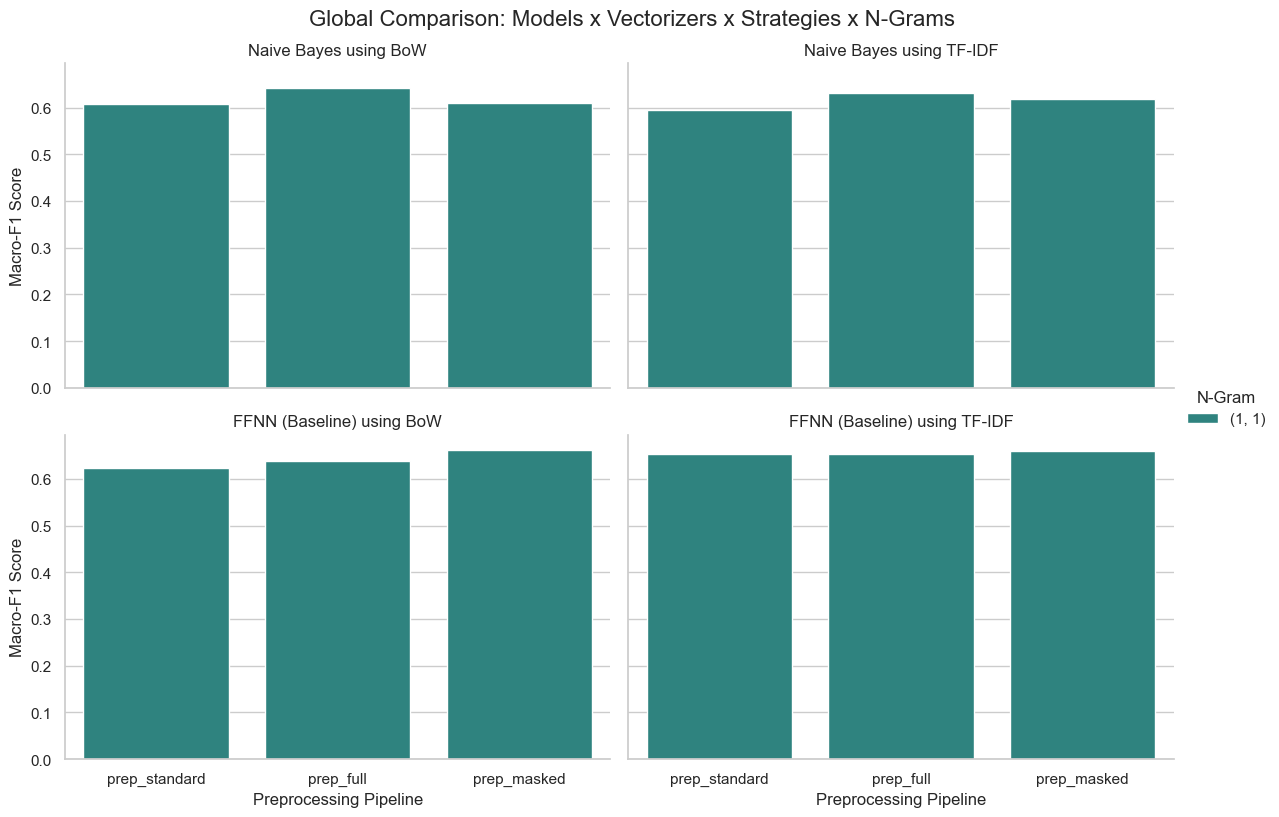


========================= FEATURE SIZE MATRIX =========================
Strategy           prep_full  prep_masked  prep_standard
Vectorizer N-Gram                                       
BoW        (1, 1)     8859.0       6697.0         6870.0
TF-IDF     (1, 1)     8859.0       6697.0         6870.0


In [ ]:
# not gpu
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from imblearn.combine import SMOTETomek
from sklearn.preprocessing import LabelEncoder

# --- Evaluation Function ---
def evaluate_model(y_true, y_pred, model_display_name, classes):
    print(f"\n================ {model_display_name} Evaluation ================")
    print(classification_report(y_true, y_pred, target_names=classes))

    macro_f1 = f1_score(y_true, y_pred, average='macro')
    acc = accuracy_score(y_true, y_pred)
    print(f"Accuracy: {acc:.4f} | Macro F1-Score: {macro_f1:.4f}")

    # Plot Confusion Matrix (FIX: Removed labels=classes to prevent integer/string mismatch)
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 3.5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title(f'CM: {model_display_name}', fontsize=10)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()


# --- Data Loading and Encoding ---
TARGET_COL = "sentiment"
df = pd.read_csv("Sentences_50Agree.txt", sep="@", header=None, names=["sentence", "sentiment"])

label_encoder = LabelEncoder()
df[TARGET_COL] = label_encoder.fit_transform(df[TARGET_COL])
classes_multiclass = label_encoder.classes_  # Keeps string names for display

# Prepare columns (Assuming these preprocessing functions are defined in your environment)
df["prep_standard"] = df["sentence"].apply(preprocess_standard)
df["prep_full"] = df["sentence"].apply(preprocess_full)
df["prep_masked"] = df["sentence"].apply(preprocess_masked)

# Setup Iterations
ngram_ranges = [
    (1, 1), (1, 2), (1, 3), (1, 4), (1, 5),
    (2, 2), (2, 3), (2, 4), (2, 5),
    (3, 3), (3, 4), (3, 5),
    (4, 4), (4, 5),
    (5, 5)
]
strategies = ["prep_standard", "prep_full", "prep_masked"]
custom_token_pattern = r'(?u)\[?\b\w[-\w\.]*\b\]?'

results = []

models = {
    "Naive Bayes": MultinomialNB(),
    "FFNN (Baseline)": MLPClassifier(
        hidden_layer_sizes=(64,),
        activation='relu',
        solver='adam',
        max_iter=50,
        early_stopping=True,
        random_state=42
    )
}

print("Starting the Grand Evaluation Loop. This may take a few minutes...")
feature_sizes = []

for strategy in strategies:
    print(f"\n---> Processing Strategy: {strategy.upper()}")

    df_clean = df.dropna(subset=[strategy, TARGET_COL]).reset_index(drop=True)
    X_train, X_test, y_train, y_test = train_test_split(
        df_clean[strategy], df_clean[TARGET_COL],
        test_size=0.20, random_state=42, stratify=df_clean[TARGET_COL]
    )

    smote_tomek = SMOTETomek(random_state=42)

    for ngram in ngram_ranges:
        print(f"     N-Gram: {ngram}")

        # --- 1. BoW Pipeline ---
        count_vect = CountVectorizer(ngram_range=ngram, token_pattern=custom_token_pattern)
        X_train_bow_raw = count_vect.fit_transform(X_train)
        X_test_bow = count_vect.transform(X_test)
        X_train_bow, y_train_resampled_bow = smote_tomek.fit_resample(X_train_bow_raw, y_train)

        feature_sizes.append({
            "Strategy": strategy,
            "Vectorizer": "BoW",
            "N-Gram": str(ngram),
            "Feature_Size": len(count_vect.get_feature_names_out())
        })

        # --- 2. TF-IDF Pipeline ---
        tfidf_vect = TfidfVectorizer(ngram_range=ngram, token_pattern=custom_token_pattern)
        X_train_tfidf_raw = tfidf_vect.fit_transform(X_train)
        X_test_tfidf = tfidf_vect.transform(X_test)
        X_train_tfidf, y_train_resampled_tfidf = smote_tomek.fit_resample(X_train_tfidf_raw, y_train)

        feature_sizes.append({
            "Strategy": strategy,
            "Vectorizer": "TF-IDF",
            "N-Gram": str(ngram),
            "Feature_Size": len(tfidf_vect.get_feature_names_out())
        })

        # --- 3. Test & Evaluate Models ---
        for model_name, model_instance in models.items():

            # --- BoW Evaluation ---
            model_instance.fit(X_train_bow, y_train_resampled_bow)
            y_pred_bow = model_instance.predict(X_test_bow)
            results.append({
                "Model": model_name,
                "Strategy": strategy,
                "Vectorizer": "BoW",
                "N-Gram": str(ngram),
                "Accuracy": accuracy_score(y_test, y_pred_bow),
                "Macro-F1": f1_score(y_test, y_pred_bow, average='macro')
            })

            # Call your custom evaluation function for BoW
            bow_title = f"{model_name} (BoW | {strategy} | {ngram})"
            # evaluate_model(y_test, y_pred_bow, bow_title, classes_multiclass)

            # --- TF-IDF Evaluation ---
            model_instance.fit(X_train_tfidf, y_train_resampled_tfidf)
            y_pred_tfidf = model_instance.predict(X_test_tfidf)
            results.append({
                "Model": model_name,
                "Strategy": strategy,
                "Vectorizer": "TF-IDF",
                "N-Gram": str(ngram),
                "Accuracy": accuracy_score(y_test, y_pred_tfidf),
                "Macro-F1": f1_score(y_test, y_pred_tfidf, average='macro')
            })

            # Call your custom evaluation function for TF-IDF
            tfidf_title = f"{model_name} (TF-IDF | {strategy} | {ngram})"
            # evaluate_model(y_test, y_pred_tfidf, tfidf_title, classes_multiclass)

results_df = pd.DataFrame(results)
print("\nEvaluation Complete!")

# --- Global Aggregations ---
big_matrix = pd.pivot_table(
    results_df,
    values='Macro-F1',
    index=['Model', 'Vectorizer', 'N-Gram'],
    columns=['Strategy']
).loc[:, ['prep_standard', 'prep_full', 'prep_masked']]

print("\n========================= THE MASTER PERFORMANCE MATRIX (Macro-F1) =========================")
print(big_matrix.round(4))
print("============================================================================================")

sns.set_theme(style="whitegrid")
g = sns.catplot(
    data=results_df,
    x='Strategy',
    y='Macro-F1',
    hue='N-Gram',
    col='Vectorizer',
    row='Model',
    kind='bar',
    palette="viridis",
    height=4,
    aspect=1.5
)
g.fig.suptitle("Global Comparison: Models x Vectorizers x Strategies x N-Grams", y=1.02, fontsize=16)
g.set_titles("{row_name} using {col_name}")
g.set_axis_labels("Preprocessing Pipeline", "Macro-F1 Score")
plt.show()

feature_sizes_df = pd.DataFrame(feature_sizes)
feature_pivot = pd.pivot_table(
    feature_sizes_df,
    values="Feature_Size",
    index=["Vectorizer", "N-Gram"],
    columns=["Strategy"]
)

print("\n========================= FEATURE SIZE MATRIX =========================")
print(feature_pivot)
print("=====================================================================")


In [ ]:
import pprint
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
pprint.pprint(df["prep_masked"])

from collections import Counter
import pprint

# Alle Wörter aus der Spalte "prep_full" in eine Liste umwandeln
all_words = []
for text in df["prep_full"]:
    if isinstance(text, str):  # Überprüfen, ob der Eintrag ein String ist
        words = text.split()  # Text in Wörter aufteilen
        all_words.extend(words)  # Wörter zur Liste hinzufügen

# Häufigkeit der Wörter zählen
word_counts = Counter(all_words)

# Die 50 häufigsten Wörter extrahieren
most_common_words = word_counts.most_common(100)

# Ergebnis anzeigen
pprint.pprint(most_common_words)


0                                                                                                                                                                                                                                                                                                      accord gran compani no plan move product russia although compani grow
1                                                                                                                                                                                                                                       technopoli plan develop stage area no less [NUMBER_MARKER] squar meter order host compani work comput technolog telecommun statement
2                                                                                                                                                                                                                    intern electron industri compani elcoteq laid ten employe

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

def evaluate_model(y_true, y_pred, model_name, classes):
    print(f"\n================ {model_name} Evaluation ================")
    print(classification_report(y_true, y_pred, target_names=classes))

    macro_f1 = f1_score(y_true, y_pred, average='macro')
    acc = accuracy_score(y_true, y_pred)
    print(f"Accuracy: {acc:.4f} | Macro F1-Score: {macro_f1:.4f}")

    # Plot Confusion Matrix
    cm = confusion_matrix(y_true, y_pred, labels=classes)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title(f'Confusion Matrix: {model_name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()


In [ ]:
# simple bow and tfidf test
classes_multiclass = sorted(list(y_train.unique()))

feature_size = None
count_vect = CountVectorizer(max_features=feature_size, ngram_range=(2,3))

X_train_bow = count_vect.fit_transform(X_train_raw)
X_test_bow = count_vect.transform(X_test_raw)

nb_bow = MultinomialNB()
nb_bow.fit(X_train_bow, y_train)
y_pred_nb_bow = nb_bow.predict(X_test_bow)

evaluate_model(y_test, y_pred_nb_bow, "Naive Bayes (boW)", classes_multiclass)

tfidf_vect = TfidfVectorizer(max_features=feature_size, token_pattern=r'(?u)\[?\b\w[-\w\.]*\b\]?')
X_train_tfidf = tfidf_vect.fit_transform(X_train_raw)
X_test_tfidf = tfidf_vect.transform(X_test_raw)

nb_tfidf = MultinomialNB()
nb_tfidf.fit(X_train_tfidf, y_train)
y_pred_nb_tfidf = nb_tfidf.predict(X_test_tfidf)
evaluate_model(y_test, y_pred_nb_tfidf, "Naive Bayes (TF-IDF)", classes_multiclass)



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 9.4 MB/s  0:00:00 eta 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [imbalanced-learn]

[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from imblearn.combine import SMOTETomek
from sklearn.preprocessing import LabelEncoder
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.base import clone

# PyTorch Imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# --- Stub Preprocessing Functions ---
def preprocess_standard(text): return text
def preprocess_full(text): return text
def preprocess_masked(text): return text

# --- Evaluation Function ---
def evaluate_model(y_true, y_pred, model_display_name, classes):
    print(f"\n================ {model_display_name} Evaluation ================")
    print(classification_report(y_true, y_pred, target_names=classes))

    macro_f1 = f1_score(y_true, y_pred, average='macro')
    acc = accuracy_score(y_true, y_pred)
    print(f"Accuracy: {acc:.4f} | Macro F1-Score: {macro_f1:.4f}")

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 3.5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title(f'CM: {model_display_name}', fontsize=10)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()


# --- GPU-Accelerated PyTorch Wrapper (Updated for Mac M1/M2/M3) ---
class PyTorchMLPClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, hidden_layer_sizes=(64,), activation='relu', solver='adam',
                 alpha=0.0001, batch_size=32, learning_rate_init=0.001,
                 max_iter=50, early_stopping=True, validation_fraction=0.1, random_state=42):
        self.hidden_layer_sizes = hidden_layer_sizes
        self.activation = activation
        self.solver = solver
        self.alpha = alpha
        self.batch_size = batch_size
        self.learning_rate_init = learning_rate_init
        self.max_iter = max_iter
        self.early_stopping = early_stopping
        self.validation_fraction = validation_fraction
        self.random_state = random_state
        self.model = None
        self.classes_ = None

        # MAC ACCELERATION: Target Apple Silicon MPS before defaulting to CPU
        if torch.backends.mps.is_available():
            self.device = torch.device("mps")
        elif torch.cuda.is_available():
            self.device = torch.device("cuda")
        else:
            self.device = torch.device("cpu")

    def fit(self, X, y):
        if self.random_state is not None:
            torch.manual_seed(self.random_state)
            np.random.seed(self.random_state)

        if hasattr(X, "toarray"):
            X = X.toarray()

        X_tensor = torch.tensor(X, dtype=torch.float32)
        y_tensor = torch.tensor(np.array(y), dtype=torch.long)

        self.classes_ = np.unique(y)
        num_classes = len(self.classes_)
        input_dim = X_tensor.shape[1]

        layers = []
        prev_dim = input_dim
        for hidden_dim in self.hidden_layer_sizes:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            if self.activation == 'relu':
                layers.append(nn.ReLU())
            elif self.activation == 'tanh':
                layers.append(nn.Tanh())
            prev_dim = hidden_dim
        layers.append(nn.Linear(prev_dim, num_classes))

        self.model = nn.Sequential(*layers).to(self.device)
        criterion = nn.CrossEntropyLoss()

        if self.solver == 'adam':
            optimizer = optim.Adam(self.model.parameters(), lr=self.learning_rate_init, weight_decay=self.alpha)
        else:
            optimizer = optim.SGD(self.model.parameters(), lr=self.learning_rate_init, weight_decay=self.alpha)

        dataset = TensorDataset(X_tensor, y_tensor)

        if self.early_stopping and self.validation_fraction > 0:
            val_size = int(len(dataset) * self.validation_fraction)
            train_size = len(dataset) - val_size
            train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])
            val_loader = DataLoader(val_dataset, batch_size=self.batch_size, shuffle=False)
        else:
            train_dataset = dataset
            val_loader = None

        train_loader = DataLoader(train_dataset, batch_size=self.batch_size, shuffle=True)

        best_loss = float('inf')
        epochs_no_improve = 0
        patience = 5

        for epoch in range(self.max_iter):
            self.model.train()
            for batch_x, batch_y in train_loader:
                batch_x, batch_y = batch_x.to(self.device), batch_y.to(self.device)

                optimizer.zero_grad()
                outputs = self.model(batch_x)
                loss = criterion(outputs, batch_y)
                loss.backward()
                optimizer.step()

            if val_loader is not None:
                self.model.eval()
                val_loss = 0.0
                with torch.no_grad():
                    for batch_x, batch_y in val_loader:
                        batch_x, batch_y = batch_x.to(self.device), batch_y.to(self.device)
                        outputs = self.model(batch_x)
                        val_loss += criterion(outputs, batch_y).item()
                val_loss /= len(val_loader)

                if val_loss < best_loss:
                    best_loss = val_loss
                    epochs_no_improve = 0
                else:
                    epochs_no_improve += 1
                    if epochs_no_improve >= patience:
                        break
        return self

    def predict(self, X):
        if hasattr(X, "toarray"):
            X = X.toarray()

        X_tensor = torch.tensor(X, dtype=torch.float32).to(self.device)

        self.model.eval()
        with torch.no_grad():
            outputs = self.model(X_tensor)
            _, predicted = torch.max(outputs, 1)

        return predicted.cpu().numpy()


# --- Data Loading and Encoding ---
TARGET_COL = "sentiment"
df = pd.read_csv("Sentences_50Agree.txt", sep="@", header=None, names=["sentence", "sentiment"])

label_encoder = LabelEncoder()
df[TARGET_COL] = label_encoder.fit_transform(df[TARGET_COL])
classes_multiclass = label_encoder.classes_

df["prep_standard"] = df["sentence"].apply(preprocess_standard)
df["prep_full"] = df["sentence"].apply(preprocess_full)
df["prep_masked"] = df["sentence"].apply(preprocess_masked)

ngram_ranges = [
    (1, 1), (1, 2), (1, 3),
    (2, 2), (2, 3),
    (3, 3),
]
strategies = ["prep_standard", "prep_full", "prep_masked"]
custom_token_pattern = r'(?u)\[?\b\w[-\w\.]*\b\]?'

results = []

models = {
    "Naive Bayes": MultinomialNB(),
    "FFNN (Baseline)": PyTorchMLPClassifier(
        hidden_layer_sizes=(64,),
        activation='relu',
        solver='adam',
        max_iter=50,
        early_stopping=True,
        random_state=42
    )
}

# Print exact hardware optimization announcement
if torch.backends.mps.is_available():
    active_device = "Apple Silicon GPU Acceleration (MPS)"
elif torch.cuda.is_available():
    active_device = "GPU Acceleration (CUDA)"
else:
    active_device = "CPU Execution Loop"

print(f"Starting the Grand Evaluation Loop on: {active_device}.")
print("Multiprocessing active on CPU for Vectorization and Resampling tasks.\n")
feature_sizes = []

for strategy in strategies:
    print(f"---> Processing Strategy: {strategy.upper()}")

    df_clean = df.dropna(subset=[strategy, TARGET_COL]).reset_index(drop=True)
    X_train, X_test, y_train, y_test = train_test_split(
        df_clean[strategy], df_clean[TARGET_COL],
        test_size=0.20, random_state=42, stratify=df_clean[TARGET_COL]
    )

    # CPU ACCELERATION: Tell SMOTE to spin up all available processor cores
    smote_tomek = SMOTETomek(random_state=42, n_jobs=-1)

    for ngram in ngram_ranges:
        print(f"     N-Gram: {ngram}")

        # --- 1. BoW Pipeline ---
        count_vect = CountVectorizer(ngram_range=ngram, token_pattern=custom_token_pattern)
        X_train_bow_raw = count_vect.fit_transform(X_train)
        X_test_bow = count_vect.transform(X_test)
        X_train_bow, y_train_resampled_bow = smote_tomek.fit_resample(X_train_bow_raw, y_train)

        feature_sizes.append({
            "Strategy": strategy,
            "Vectorizer": "BoW",
            "N-Gram": str(ngram),
            "Feature_Size": len(count_vect.get_feature_names_out())
        })

        # --- 2. TF-IDF Pipeline ---
        tfidf_vect = TfidfVectorizer(ngram_range=ngram, token_pattern=custom_token_pattern)
        X_train_tfidf_raw = tfidf_vect.fit_transform(X_train)
        X_test_tfidf = tfidf_vect.transform(X_test)
        X_train_tfidf, y_train_resampled_tfidf = smote_tomek.fit_resample(X_train_tfidf_raw, y_train)

        feature_sizes.append({
            "Strategy": strategy,
            "Vectorizer": "TF-IDF",
            "N-Gram": str(ngram),
            "Feature_Size": len(tfidf_vect.get_feature_names_out())
        })

        # --- 3. Test & Evaluate Models ---
        for model_name, original_model_instance in models.items():

            model_instance = clone(original_model_instance)

            # --- BoW Evaluation ---
            model_instance.fit(X_train_bow, y_train_resampled_bow)
            y_pred_bow = model_instance.predict(X_test_bow)
            results.append({
                "Model": model_name,
                "Strategy": strategy,
                "Vectorizer": "BoW",
                "N-Gram": str(ngram),
                "Accuracy": accuracy_score(y_test, y_pred_bow),
                "Macro-F1": f1_score(y_test, y_pred_bow, average='macro')
            })

            model_instance = clone(original_model_instance)

            # --- TF-IDF Evaluation ---
            model_instance.fit(X_train_tfidf, y_train_resampled_tfidf)
            y_pred_tfidf = model_instance.predict(X_test_tfidf)
            results.append({
                "Model": model_name,
                "Strategy": strategy,
                "Vectorizer": "TF-IDF",
                "N-Gram": str(ngram),
                "Accuracy": accuracy_score(y_test, y_pred_tfidf),
                "Macro-F1": f1_score(y_test, y_pred_tfidf, average='macro')
            })

results_df = pd.DataFrame(results)
print("\nEvaluation Complete!")

# --- Global Aggregations ---
big_matrix = pd.pivot_table(
    results_df,
    values='Macro-F1',
    index=['Model', 'Vectorizer', 'N-Gram'],
    columns=['Strategy']
).loc[:, ['prep_standard', 'prep_full', 'prep_masked']]

print("\n========================= THE MASTER PERFORMANCE MATRIX (Macro-F1) =========================")
print(big_matrix.round(4))
print("============================================================================================")


Starting the Grand Evaluation Loop on: Apple Silicon GPU Acceleration (MPS).
Multiprocessing active on CPU for Vectorization and Resampling tasks.

---> Processing Strategy: PREP_STANDARD
     N-Gram: (1, 1)
     N-Gram: (1, 2)
     N-Gram: (1, 3)
     N-Gram: (2, 2)
     N-Gram: (2, 3)
     N-Gram: (3, 3)
---> Processing Strategy: PREP_FULL
     N-Gram: (1, 1)
     N-Gram: (1, 2)
     N-Gram: (1, 3)
     N-Gram: (2, 2)
     N-Gram: (2, 3)
     N-Gram: (3, 3)
---> Processing Strategy: PREP_MASKED
     N-Gram: (1, 1)
     N-Gram: (1, 2)
     N-Gram: (1, 3)
     N-Gram: (2, 2)
     N-Gram: (2, 3)
     N-Gram: (3, 3)

Evaluation Complete!

========================= THE MASTER PERFORMANCE MATRIX (Macro-F1) =========================
Strategy                           prep_standard  prep_full  prep_masked
Model           Vectorizer N-Gram                                       
FFNN (Baseline) BoW        (1, 1)         0.6469     0.6469       0.6469
                           (1, 2)         0

In [ ]:
results_df = pd.DataFrame(results)
print("\nEvaluation Complete!")

# --- 1. Save the Raw Data for Later Plotting (Crucial) ---
# This keeps every single row, model, and metric intact
results_df.to_csv("raw_evaluation_results.csv", index=False)
print("Saved raw results to 'raw_evaluation_results.csv'")

# --- 2. Save your Summary Matrix ---
big_matrix = pd.pivot_table(
    results_df,
    values='Macro-F1',
    index=['Model', 'Vectorizer', 'N-Gram'],
    columns=['Strategy']
).loc[:, ['prep_standard', 'prep_full', 'prep_masked']]

# Save the pivot table (index=True because Model/Vectorizer/N-Gram are the index)
big_matrix.to_csv("macro_f1_pivot_matrix.csv", index=True)
print("Saved pivot matrix to 'macro_f1_pivot_matrix.csv'")



Evaluation Complete!
Saved raw results to 'raw_evaluation_results.csv'
Saved pivot matrix to 'macro_f1_pivot_matrix.csv'


In [ ]:
print("\n========== PHASE 2: GRID SEARCH ON THE WINNING COMBINATION ==========")

# 1. Re-isolate the winning data configuration
BEST_STRATEGY = "prep_masked"
BEST_NGRAM = (1, 2)

df_winner = df.dropna(subset=[BEST_STRATEGY, TARGET_COL]).reset_index(drop=True)
X_train_win, X_test_win, y_train_win, y_test_win = train_test_split(
    df_winner[BEST_STRATEGY], df_winner[TARGET_COL],
    test_size=0.20, random_state=42, stratify=df_winner[TARGET_COL]
)

final_vect = TfidfVectorizer(ngram_range=BEST_NGRAM, token_pattern=custom_token_pattern)
X_train_final = final_vect.fit_transform(X_train_win)
X_test_final = final_vect.transform(X_test_win)

# 2. PyTorch Compatible Grid Search Parameter Configuration Matrix
param_grid = {
    'hidden_layer_sizes': [(32,), (64,), (32, 32), (64, 32)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam', 'sgd'],
    'alpha': [0.0001, 0.001, 0.01],
    'batch_size': [16, 32],
    'learning_rate_init': [0.001, 0.01, 0.1],
    'max_iter': [20, 50, 100],
    'early_stopping': [True],
    'validation_fraction': [0.1],
    'random_state': [42]
}

# Initializing PyTorch model abstraction instead of MLPClassifier
pytorch_mlp = PyTorchMLPClassifier()
grid_search = GridSearchCV(
    estimator=pytorch_mlp,
    param_grid=param_grid,
    cv=3,
    scoring='f1_macro',
    n_jobs=1,
    verbose=2
)

print(f"Executing Grid Search on {X_train_final.shape[0]} samples and {X_train_final.shape[1]} features...")
grid_search.fit(X_train_final, y_train_win)

print(f"\nBest parameters found: {grid_search.best_params_}")
print(f"Best cross-validation F1-score: {grid_search.best_score_:.4f}")

# 3. Final Evaluation using PyTorch Architecture output
best_model = grid_search.best_estimator_
y_pred_mlp = best_model.predict(X_test_final)

evaluate_model(y_test_win, y_pred_mlp, f"Tuned PyTorch FFNN ({BEST_STRATEGY}, TF-IDF, {BEST_NGRAM})", classes_multiclass)



========== PHASE 2: GRID SEARCH ON THE WINNING COMBINATION ==========
Executing Grid Search on 3876 samples and 52313 features...
Fitting 3 folds for each of 864 candidates, totalling 2592 fits


KeyboardInterrupt: 

In [ ]:
# old
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from imblearn.combine import SMOTETomek
from sklearn.preprocessing import LabelEncoder
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.base import clone

# PyTorch Imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import nltk
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag

# --- ERWEITERTER DOWNLOAD-BLOCK (Fix für den LookupError) ---
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)                       # Neu für modernisierte Tokenizer
nltk.download('wordnet', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)   # Neu für NLTK POS-Tagging

# ==========================================
# 1. PREPROCESSING CONFIGURATIONS & MAPS
# ==========================================
MONTH_MAP = {
    'jan': '01', 'january': '01', 'feb': '02', 'february': '02',
    'mar': '03', 'march': '03', 'apr': '04', 'april': '04',
    'may': '05', 'jun': '06', 'june': '06',
    'jul': '07', 'july': '07', 'aug': '08', 'august': '08',
    'sep': '09', 'september': '09', 'oct': '10', 'october': '10',
    'nov': '11', 'november': '11', 'dec': '12', 'december': '12'
}

WRITTEN_NUMS = {
    re.compile(r'\bone\b', re.I): '1', re.compile(r'\btwo\b', re.I): '2',
    re.compile(r'\bthree\b', re.I): '3', re.compile(r'\bfour\b', re.I): '4',
    re.compile(r'\bfive\b', re.I): '5', re.compile(r'\bsix\b', re.I): '6',
    re.compile(r'\bseven\b', re.I): '7', re.compile(r'\beight\b', re.I): '8',
    re.compile(r'\bnine\b', re.I): '9', re.compile(r'\bten\b', re.I): '10'
}

FINANCIAL_NOISE_STOPWORDS = {
    '-', "''", "'", '2009', '2008', '2007', '2006', '2010', '2005', '1', '2',
    'year', 'period', 'quarter', 'today', 'first', 'end', 'finnish', 'finland',
    'helsinki', 'hel', 'nokia', 'corporate', 'corporation', 'oyj', 'oy', 'omx', 'group', 'company',
    'said', 'also', 'include', 'including', 'accord', 'according', 'use', 'per', 'part', 'would',
    'base', 'provide'
}

PRESERVED_WORDS = {
    'below', 'but', 'down', 'few', 'more', 'no', 'nor',
    'not', 'only', 'over', 'should', 'up'
}

english_defaults = set(stopwords.words('english'))
CUSTOM_STOPWORDS = (english_defaults | FINANCIAL_NOISE_STOPWORDS) - PRESERVED_WORDS

lemmatizer = WordNetLemmatizer()

PHONE_NUMBER = re.compile(r"(?<!\w)\+[\d\s\-\(\)]{6,20}(?!\w)")
STOCK_TICKER = re.compile(r"\([A-Z]+(\s*:\s*[A-Z0-9]+)?\)")
PHONE_PLACEHOLDER = "__PHONE__"

DATE_RANGE_WITH_YEAR = re.compile(r"\b([a-zA-Z]+)\s+(\d{1,2})\s*-\s*([a-zA-Z]+)\s+(\d{1,2})\s*,?\s*(\d{4})\b", re.I)
MONTH_MONTH_YEAR = re.compile(r"\b([a-zA-Z]+)-([a-zA-Z]+)\s+(\d{4})\b", re.I)
MONTH_MONTH = re.compile(r"\b([a-zA-Z]+)-([a-zA-Z]+)\b", re.I)
DAY_MONTH_YEAR = re.compile(r"\b(\d{1,2})\s+([a-zA-Z]+)\s+(\d{4})\b", re.I)
MONTH_DAY_YEAR = re.compile(r"\b([a-zA-Z]+)\s+(\d{1,2})[,\s]+(\d{4})\b", re.I)
MONTH_YEAR = re.compile(r"\b([a-zA-Z]+)\s+(\d{4})\b", re.I)
YEAR_MONTH = re.compile(r"\b(\d{4})\s+([a-zA-Z]+)\b", re.I)

EARLY_CLEANUP = [
    (re.compile(r"(x[0-9a-fA-F]{4}|[^\x00-\x7F]+)"), " "),
    (re.compile(r"(\d+)(st|nd|rd|th)", re.I), r"\1"),
    (re.compile(r"(\d)\s(\d)"), r"\1\2"),
    (re.compile(r"(\.)\s(\d)"), r"\1\2"),
    (re.compile(r"(\d)\s(\.)"), r"\1\2"),
]

FINANCIAL_CLEANUP = [
    (re.compile(r"x20ac"), "eur"), (re.compile(r"\$"), "usd"), (re.compile(r"\%"), "pct"),
    (re.compile(r"(\d+\.?\d*)\s*(percent|per cent)"), r"\1pct"),
    (re.compile(r"\b(euros?|SEK|sek)\b", re.I), "eur"), (re.compile(r"\bmln\b", re.I), "mn"),
    (re.compile(r"\b(\d+\.?\d*)\s*billion\b", re.I), r"\1bn"),
    (re.compile(r"\b(\d+\.?\d*)\s*million\b", re.I), r"\1mn"),
    (re.compile(r"(eur|usd|gbp|jpy|chf|sek)\s*([-+]?\d+\.?\d*)\s*(m|mn|bn|k|pct|%)", re.I), r"\1\2\3"),
    (re.compile(r"([-+]?\d+\.?\d*)\s*(m|mn|bn|k|pct|%)", re.I), r"\1\2"),
    (re.compile(r"(eur|usd|gbp|jpy|chf|sek)\s*([-+]?\d+\.?\d*)", re.I), r"\1\2"),
    (re.compile(r"([-+]?\d+\.?\d*)\s*(eur|usd|gbp|jpy|chf|sek|gmt)(?!\d)", re.I), r"\2\1"),
    (re.compile(r"(\d+\.?\d*)\s*(m|mn|bn|k|pct)\s*(eur|usd|gbp|jpy|chf|sek)", re.I), r"\3\1\2"),
    (re.compile(r"(eur|usd|gbp|jpy|chf|sek)(\d+)\s*,\s*(\d+)\s*(m|mn|bn|k)", re.I), r"\1\2,\3\4"),
    (re.compile(r"(\d+)(pct|mn|bn|k|%)\s*-\s*(\d+)\2", re.I), r"\1-\3\2"),
    (re.compile(r"(\d+),(\d+)"), r"\1.\2"),
]

LATE_CLEANUP = [
    (re.compile(r"(\d{1,2}:\d{2})\s*(am|pm)\b", re.I), r"\1\2"),
    (re.compile(r"\bsq\s*m\b", re.I), "sqm"),
    (re.compile(r"(\d+)\s*(sqm|m|km|kg|g)", re.I), r"\1\2"),
    (re.compile(r"\b([a-zA-Z]+)\s*(\d{1,2})\s*-\s*([a-zA-Z]+)\s*(\d{1,2})\b"), r"\1\2-\3\4"),
    (re.compile(r"(?<!\d)(\d{4})-(\d{2})(?!\d)"), r"\1-20\2"),
    (re.compile(r"\b(\d{1,2})-(\d{4})\b"), lambda m: f"{m.group(2)}-{m.group(1).zfill(2)}"),
    (re.compile(r"(?<!\d)[^\w\s'=%-]|[^\w\s'=%-](?!\d)"), ""),
    (re.compile(r"\s+"), " "), (re.compile(r"\s*'(\w+)"), ""),
]

def normalize_dates_smart(text):
    def repl_range_year(m):
        m1, m2 = m.group(1).lower(), m.group(3).lower()
        if m1 in MONTH_MAP and m2 in MONTH_MAP:
            return f"{m.group(5)}-{MONTH_MAP[m1]}-{m.group(2).zfill(2)} to {m.group(5)}-{MONTH_MAP[m2]}-{m.group(4).zfill(2)}"
        return m.group(0)
    text = DATE_RANGE_WITH_YEAR.sub(repl_range_year, text)

    def repl_mo_mo_yr(m):
        m1, m2 = m.group(1).lower(), m.group(2).lower()
        if m1 in MONTH_MAP and m2 in MONTH_MAP:
            return f"{m.group(3)}-{MONTH_MAP[m1]}-{MONTH_MAP[m2]}"
        return m.group(0)
    text = MONTH_MONTH_YEAR.sub(repl_mo_mo_yr, text)

    def repl_mo_mo(m):
        m1, m2 = m.group(1).lower(), m.group(2).lower()
        if m1 in MONTH_MAP and m2 in MONTH_MAP:
            return f"{MONTH_MAP[m1]}-{MONTH_MAP[m2]}"
        return m.group(0)
    text = MONTH_MONTH.sub(repl_mo_mo, text)

    def repl_d_m_y(m):
        mo = m.group(2).lower()
        if mo in MONTH_MAP:
            return f"{m.group(3)}-{MONTH_MAP[mo]}-{m.group(1).zfill(2)}"
        return m.group(0)
    text = DAY_MONTH_YEAR.sub(repl_d_m_y, text)

    def repl_m_d_y(m):
        mo = m.group(1).lower()
        if mo in MONTH_MAP:
            return f"{m.group(3)}-{MONTH_MAP[mo]}-{m.group(2).zfill(2)}"
        return m.group(0)
    text = MONTH_DAY_YEAR.sub(repl_m_d_y, text)

    def repl_m_y(m):
        mo = m.group(1).lower()
        if mo in MONTH_MAP:
            return f"{m.group(2)}-{MONTH_MAP[mo]}"
        return m.group(0)
    text = MONTH_YEAR.sub(repl_m_y, text)

    def repl_y_m(m):
        mo = m.group(2).lower()
        if mo in MONTH_MAP:
            return f"{m.group(1)}-{MONTH_MAP[mo]}"
        return m.group(0)
    text = YEAR_MONTH.sub(repl_y_m, text)
    return text

def _normalize_text_pipeline(text):
    if not isinstance(text, str): return ""
    text = text.lower()
    phones = re.findall(PHONE_NUMBER, text)
    text = PHONE_NUMBER.sub(PHONE_PLACEHOLDER, text)
    text = STOCK_TICKER.sub(lambda m: m.group(0).replace(" ", ""), text)
    for reg, repl in EARLY_CLEANUP: text = reg.sub(repl, text)
    for word_regex, num in WRITTEN_NUMS.items(): text = word_regex.sub(num, text)
    text = normalize_dates_smart(text)
    text = re.sub(r"(?<=\d),(?=\d)", "", text)
    for reg, repl in (FINANCIAL_CLEANUP + LATE_CLEANUP): text = reg.sub(repl, text)
    for p in phones: text = text.replace(PHONE_PLACEHOLDER, p.replace(" ", ""), 1)
    return text

def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith('J'): return wordnet.ADJ
    elif treebank_tag.startswith('V'): return wordnet.VERB
    elif treebank_tag.startswith('N'): return wordnet.NOUN
    elif treebank_tag.startswith('R'): return wordnet.ADV
    else: return wordnet.NOUN

# ==========================================
# 2. LEMMATIZATION PREPROCESSING STRATEGIES
# ==========================================
def preprocess_full(text):
    text = _normalize_text_pipeline(text)
    tokens = text.split()
    tagged_tokens = pos_tag(tokens)

    lemmatized_tokens = []
    for word, tag in tagged_tokens:
        word_pos = get_wordnet_pos(tag)
        lemma = lemmatizer.lemmatize(word, pos=word_pos)
        if lemma not in CUSTOM_STOPWORDS:
            lemmatized_tokens.append(lemma)
    return " ".join(lemmatized_tokens).strip()

def preprocess_masked(text):
    text = _normalize_text_pipeline(text)
    text = re.sub(r'\+[\d\-()]{6,20}', ' [PHONE_MARKER] ', text)
    text = re.sub(r'\b(eur|usd|gbp|jpy|chf|sek)\d+\.?\d*(mn|bn|k|pct)?\b', ' [MONEY_METRIC] ', text)
    text = re.sub(r'\b\d+\.?\d*pct\b', ' [PERCENT_METRIC] ', text)
    text = re.sub(r'\b\d{4}-\d{2}-\d{2}\b', ' [DATE_MARKER] ', text)
    text = re.sub(r'\b\d{4}-\d{2}\b', ' [DATE_MARKER] ', text)
    text = re.sub(r'\b\d{2}-\d{2}\b', ' [DATE_MARKER] ', text)
    text = re.sub(r'\b(19\d{2}|20\d{2})\b', ' [DATE_MARKER] ', text)
    text = re.sub(r'\b\d{1,2}:\d{2}(am|pm)\b', ' [TIME_MARKER] ', text)
    text = re.sub(r'\b\d+\.?\d*(sqm|km|kg|m|g)\b', ' [MEASUREMENT_MARKER] ', text)
    text = re.sub(r'\b\d+\.?\d*\b', ' [NUMBER_MARKER] ', text)

    tokens = text.split()
    tagged_tokens = pos_tag(tokens)

    mask_placeholders = {
        '[PHONE_MARKER]', '[MONEY_METRIC]', '[PERCENT_METRIC]',
        '[DATE_MARKER]', '[TIME_MARKER]', '[MEASUREMENT_MARKER]', '[NUMBER_MARKER]'
    }
    processed_tokens = []
    for word, tag in tagged_tokens:
        if word in mask_placeholders:
            processed_tokens.append(word)
        else:
            word_pos = get_wordnet_pos(tag)
            lemma = lemmatizer.lemmatize(word, pos=word_pos)
            if lemma not in CUSTOM_STOPWORDS:
                processed_tokens.append(lemma)
    return re.sub(r'\s+', ' ', " ".join(processed_tokens)).strip()

def preprocess_standard(text):
    if not isinstance(text, str): return ""
    text = text.lower()
    text = re.sub(r'[^\w\s]', ' ', text)
    tokens = text.split()
    tagged_tokens = pos_tag(tokens)

    processed_tokens = []
    for word, tag in tagged_tokens:
        word_pos = get_wordnet_pos(tag)
        lemma = lemmatizer.lemmatize(word, pos=word_pos)
        if lemma not in CUSTOM_STOPWORDS:
            processed_tokens.append(lemma)
    return " ".join(processed_tokens).strip()

# ==========================================
# 3. PYTORCH MODEL WRAPPER
# ==========================================
class PyTorchMLPClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, hidden_layer_sizes=(64,), activation='relu', solver='adam',
                 alpha=0.0001, batch_size=32, learning_rate_init=0.001,
                 max_iter=50, early_stopping=True, validation_fraction=0.1, random_state=42):
        self.hidden_layer_sizes = hidden_layer_sizes
        self.activation = activation
        self.solver = solver
        self.alpha = alpha
        self.batch_size = batch_size
        self.learning_rate_init = learning_rate_init
        self.max_iter = max_iter
        self.early_stopping = early_stopping
        self.validation_fraction = validation_fraction
        self.random_state = random_state
        self.model = None
        self.classes_ = None

        if torch.backends.mps.is_available():
            self.device = torch.device("mps")
        elif torch.cuda.is_available():
            self.device = torch.device("cuda")
        else:
            self.device = torch.device("cpu")

    def fit(self, X, y):
        if self.random_state is not None:
            torch.manual_seed(self.random_state)
            np.random.seed(self.random_state)

        if hasattr(X, "toarray"): X = X.toarray()
        X_tensor = torch.tensor(X, dtype=torch.float32)
        y_tensor = torch.tensor(np.array(y), dtype=torch.long)

        self.classes_ = np.unique(y)
        num_classes = len(self.classes_)
        input_dim = X_tensor.shape[1]

        layers = []
        prev_dim = input_dim
        for hidden_dim in self.hidden_layer_sizes:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            if self.activation == 'relu': layers.append(nn.ReLU())
            elif self.activation == 'tanh': layers.append(nn.Tanh())
            prev_dim = hidden_dim
        layers.append(nn.Linear(prev_dim, num_classes))

        self.model = nn.Sequential(*layers).to(self.device)
        criterion = nn.CrossEntropyLoss()

        if self.solver == 'adam':
            optimizer = optim.Adam(self.model.parameters(), lr=self.learning_rate_init, weight_decay=self.alpha)
        else:
            optimizer = optim.SGD(self.model.parameters(), lr=self.learning_rate_init, weight_decay=self.alpha)

        dataset = TensorDataset(X_tensor, y_tensor)

        if self.early_stopping and self.validation_fraction > 0:
            val_size = int(len(dataset) * self.validation_fraction)
            train_size = len(dataset) - val_size
            train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])
            val_loader = DataLoader(val_dataset, batch_size=self.batch_size, shuffle=False)
        else:
            train_dataset = dataset
            val_loader = None

        train_loader = DataLoader(train_dataset, batch_size=self.batch_size, shuffle=True)

        best_loss = float('inf')
        epochs_no_improve = 0
        patience = 5

        for epoch in range(self.max_iter):
            self.model.train()
            for batch_x, batch_y in train_loader:
                batch_x, batch_y = batch_x.to(self.device), batch_y.to(self.device)
                optimizer.zero_grad()
                outputs = self.model(batch_x)
                loss = criterion(outputs, batch_y)
                loss.backward()
                optimizer.step()

            if val_loader is not None:
                self.model.eval()
                val_loss = 0.0
                with torch.no_grad():
                    for batch_x, batch_y in val_loader:
                        batch_x, batch_y = batch_x.to(self.device), batch_y.to(self.device)
                        outputs = self.model(batch_x)
                        val_loss += criterion(outputs, batch_y).item()
                val_loss /= len(val_loader)

                if val_loss < best_loss:
                    best_loss = val_loss
                    epochs_no_improve = 0
                else:
                    epochs_no_improve += 1
                    if epochs_no_improve >= patience: break
        return self

    def predict(self, X):
        if hasattr(X, "toarray"): X = X.toarray()
        X_tensor = torch.tensor(X, dtype=torch.float32).to(self.device)
        self.model.eval()
        with torch.no_grad():
            outputs = self.model(X_tensor)
            _, predicted = torch.max(outputs, 1)
        return predicted.cpu().numpy()

# ==========================================
# 4. MAIN GRAND EVALUATION LOOP
# ==========================================
TARGET_COL = "sentiment"
df = pd.read_csv("Sentences_50Agree.txt", sep="@", header=None, names=["sentence", "sentiment"])

label_encoder = LabelEncoder()
df[TARGET_COL] = label_encoder.fit_transform(df[TARGET_COL])

print("Applying real preprocessing routines to the text dataset...")
df["prep_standard"] = df["sentence"].apply(preprocess_standard)
df["prep_full"] = df["sentence"].apply(preprocess_full)
df["prep_masked"] = df["sentence"].apply(preprocess_masked)

ngram_ranges = [(1, 1), (1, 2), (1, 3), (2, 2), (2, 3), (3, 3)]
strategies = ["prep_standard", "prep_full", "prep_masked"]
custom_token_pattern = r'(?u)\[?\b\w[-\w\.]*\b\]?'

results = []
models = {
    "Naive Bayes": MultinomialNB(),
    "FFNN (Baseline)": PyTorchMLPClassifier(
        hidden_layer_sizes=(64,), activation='relu', solver='adam',
        max_iter=50, early_stopping=True, random_state=42
    )
}

if torch.backends.mps.is_available(): active_device = "Apple Silicon GPU Acceleration (MPS)"
elif torch.cuda.is_available(): active_device = "GPU Acceleration (CUDA)"
else: active_device = "CPU Execution Loop"

print(f"Starting evaluation on: {active_device}.\n")

for strategy in strategies:
    print(f"---> Processing Strategy: {strategy.upper()}")
    df_clean = df.dropna(subset=[strategy, TARGET_COL]).reset_index(drop=True)

    X_train, X_test, y_train, y_test = train_test_split(
        df_clean[strategy], df_clean[TARGET_COL],
        test_size=0.20, random_state=42, stratify=df_clean[TARGET_COL]
    )

    from imblearn.combine import SMOTETomek
    smote_tomek = SMOTETomek(random_state=42, n_jobs=-1)

    for ngram in ngram_ranges:
        count_vect = CountVectorizer(ngram_range=ngram, token_pattern=custom_token_pattern)
        X_train_bow_raw = count_vect.fit_transform(X_train)
        X_test_bow = count_vect.transform(X_test)
        X_train_bow, y_train_resampled_bow = smote_tomek.fit_resample(X_train_bow_raw, y_train)

        tfidf_vect = TfidfVectorizer(ngram_range=ngram, token_pattern=custom_token_pattern)
        X_train_tfidf_raw = tfidf_vect.fit_transform(X_train)
        X_test_tfidf = tfidf_vect.transform(X_test)
        X_train_tfidf, y_train_resampled_tfidf = smote_tomek.fit_resample(X_train_tfidf_raw, y_train)

        for model_name, original_model_instance in models.items():
            model_instance = clone(original_model_instance)
            model_instance.fit(X_train_bow, y_train_resampled_bow)
            y_pred_bow = model_instance.predict(X_test_bow)
            results.append({
                "Model": model_name, "Strategy": strategy, "Vectorizer": "BoW", "N-Gram": str(ngram),
                "Accuracy": accuracy_score(y_test, y_pred_bow), "Macro-F1": f1_score(y_test, y_pred_bow, average='macro')
            })

            model_instance = clone(original_model_instance)
            model_instance.fit(X_train_tfidf, y_train_resampled_tfidf)
            y_pred_tfidf = model_instance.predict(X_test_tfidf)
            results.append({
                "Model": model_name, "Strategy": strategy, "Vectorizer": "TF-IDF", "N-Gram": str(ngram),
                "Accuracy": accuracy_score(y_test, y_pred_tfidf), "Macro-F1": f1_score(y_test, y_pred_tfidf, average='macro')
            })

results_df = pd.DataFrame(results)
results_df.to_csv("Master_performance_matrix.csv")
big_matrix = pd.pivot_table(
    results_df, values='Macro-F1', index=['Model', 'Vectorizer', 'N-Gram'], columns=['Strategy']
).loc[:, ['prep_standard', 'prep_full', 'prep_masked']]

print("\n========================= THE MASTER PERFORMANCE MATRIX (Macro-F1) =========================")
print(big_matrix.round(4))
print("============================================================================================")


Applying real preprocessing routines to the text dataset...
Starting evaluation on: Apple Silicon GPU Acceleration (MPS).

---> Processing Strategy: PREP_STANDARD
---> Processing Strategy: PREP_FULL
---> Processing Strategy: PREP_MASKED

========================= THE MASTER PERFORMANCE MATRIX (Macro-F1) =========================
Strategy                           prep_standard  prep_full  prep_masked
Model           Vectorizer N-Gram                                       
FFNN (Baseline) BoW        (1, 1)         0.6301     0.6313       0.6289
                           (1, 2)         0.5850     0.6182       0.6227
                           (1, 3)         0.5707     0.6057       0.6169
                           (2, 2)         0.4093     0.4020       0.4526
                           (2, 3)         0.3717     0.3691       0.4304
                           (3, 3)         0.2702     0.2372       0.3099
                TF-IDF     (1, 1)         0.6731     0.7066       0.7002
            


Generating publication-quality performance grid...
Graphic saved successfully as 'sentiment_evaluation_matrix.png'!


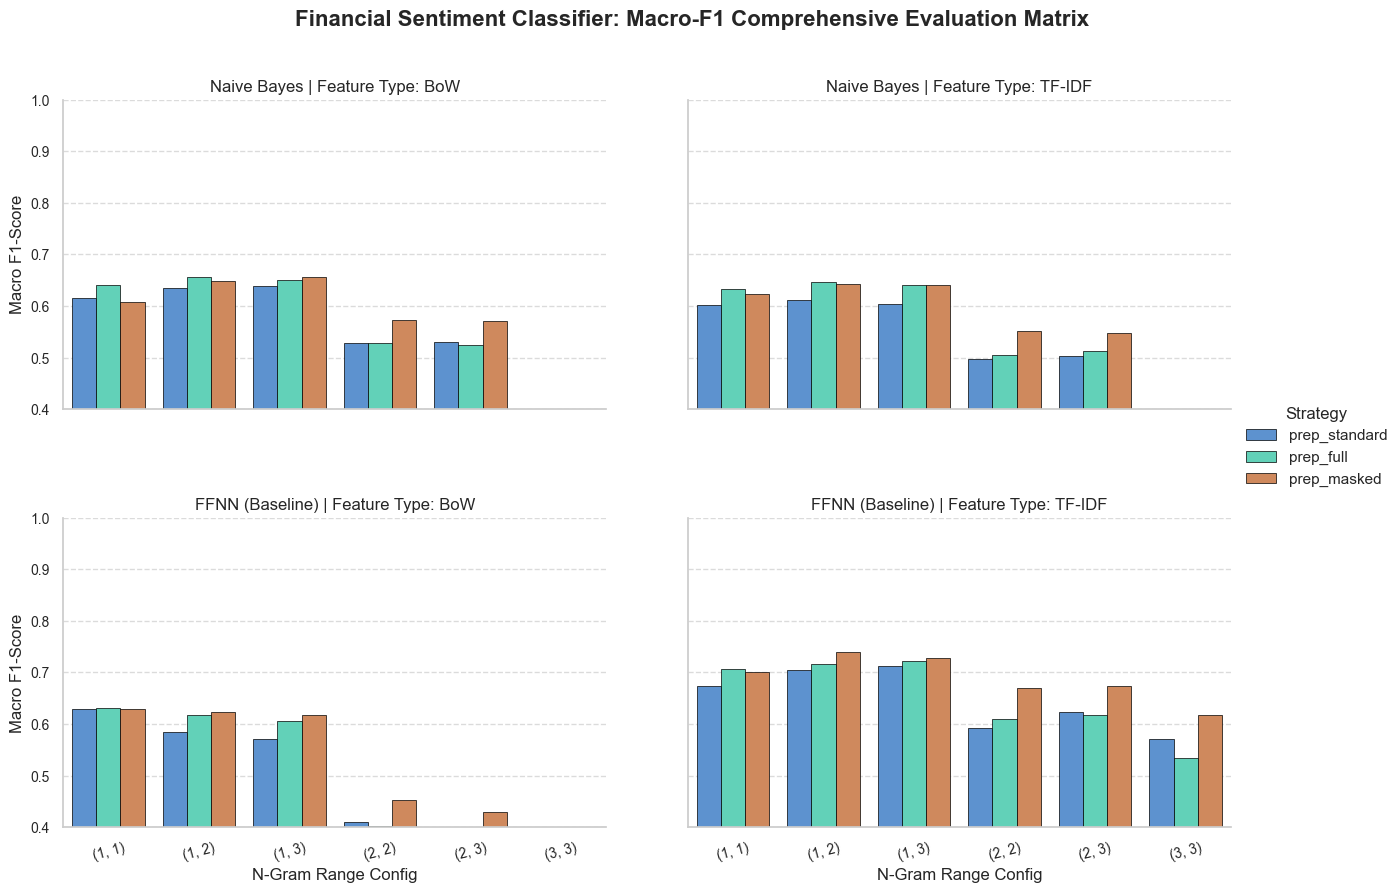

In [9]:
# ==========================================
# 5. SCIENTIFIC VISUALIZATION BLOCK
# ==========================================

# Set high-quality styling for scientific reporting
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 16
})

# Define a clean, academic, colorblind-friendly palette
strategy_colors = {
    'prep_standard': '#4A90E2',  # Soft Blue
    'prep_full': '#50E3C2',      # Mint Green
    'prep_masked': '#E2844A'     # Muted Orange
}

print("\nGenerating publication-quality performance grid...")

# Initialize the structural grid: Rows = Models, Columns = Vectorizers
g = sns.catplot(
    data=results_df,
    x="N-Gram",
    y="Macro-F1",
    hue="Strategy",
    row="Model",
    col="Vectorizer",
    kind="bar",
    palette=strategy_colors,
    edgecolor="black",
    linewidth=0.5,
    height=4.5,
    aspect=1.4,
    sharex=True,
    sharey=True
)

# Refine layouts, axis titles, and limit parameters cleanly
g.set_axis_labels("N-Gram Range Config", "Macro F1-Score")
g.set_titles(row_template="{row_name}", col_template="Feature Type: {col_name}")

# Fine-tune visual details for each subplot
for ax in g.axes.flat:
    # Set realistic boundaries to highlight differences (adjust min bound based on your data)
    ax.set_ylim(0.40, 1.00)
    ax.yaxis.grid(True, linestyle="--", alpha=0.7)
    ax.xaxis.grid(False) # Drop vertical grids to increase scannability

    # Rotate text labels slightly to prevent overlapping text elements
    for label in ax.get_xticklabels():
        label.set_rotation(15)

# Adjust margins and fix the position of the legend safely
g.fig.subplots_adjust(top=0.88, hspace=0.35, wspace=0.15)
g.fig.suptitle("Financial Sentiment Classifier: Macro-F1 Comprehensive Evaluation Matrix", weight="bold")

# Save a crisp, high-resolution vector image for your report text editor
plt.savefig("sentiment_evaluation_matrix.png", dpi=300, bbox_inches='tight')
print("Graphic saved successfully as 'sentiment_evaluation_matrix.png'!")
plt.show()


In [ ]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.base import clone

# Balancing / Resampling Imports
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek

# PyTorch Imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import nltk
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag

# --- DOWNLOAD-BLOCK ---
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)

# ==========================================
# 1. PREPROCESSING CONFIGURATIONS & MAPS
# ==========================================
MONTH_MAP = {
    'jan': '01', 'january': '01', 'feb': '02', 'february': '02',
    'mar': '03', 'march': '03', 'apr': '04', 'april': '04',
    'may': '05', 'jun': '06', 'june': '06',
    'jul': '07', 'july': '07', 'aug': '08', 'august': '08',
    'sep': '09', 'september': '09', 'oct': '10', 'october': '10',
    'nov': '11', 'november': '11', 'dec': '12', 'december': '12'
}

WRITTEN_NUMS = {
    re.compile(r'\bone\b', re.I): '1', re.compile(r'\btwo\b', re.I): '2',
    re.compile(r'\bthree\b', re.I): '3', re.compile(r'\bfour\b', re.I): '4',
    re.compile(r'\bfive\b', re.I): '5', re.compile(r'\bsix\b', re.I): '6',
    re.compile(r'\bseven\b', re.I): '7', re.compile(r'\beight\b', re.I): '8',
    re.compile(r'\bnine\b', re.I): '9', re.compile(r'\bten\b', re.I): '10'
}

FINANCIAL_NOISE_STOPWORDS = {
    '-', "''", "'",
    'year', 'period', 'quarter', 'today', 'first', 'end', 'finnish', 'finland',
    'helsinki', 'hel', 'nokia', 'corporate', 'corporation', 'oyj', 'oy', 'omx', 'group', 'company',
    'said', 'also', 'include', 'including', 'accord', 'according', 'use', 'per', 'part', 'would',
    'base', 'provide'
}

PRESERVED_WORDS = {
    'below', 'but', 'down', 'few', 'more', 'no', 'nor',
    'not', 'only', 'over', 'should', 'up',
}

english_defaults = set(stopwords.words('english'))
CUSTOM_STOPWORDS = (english_defaults | FINANCIAL_NOISE_STOPWORDS) - PRESERVED_WORDS

lemmatizer = WordNetLemmatizer()

PHONE_NUMBER = re.compile(r"(?<!\w)\+[\d\s\-\(\)]{6,20}(?!\w)")
STOCK_TICKER = re.compile(r"\([A-Z]+(\s*:\s*[A-Z0-9]+)?\)")
PHONE_PLACEHOLDER = "__PHONE__"

DATE_RANGE_WITH_YEAR = re.compile(r"\b([a-zA-Z]+)\s+(\d{1,2})\s*-\s*([a-zA-Z]+)\s+(\d{1,2})\s*,?\s*(\d{4})\b", re.I)
MONTH_MONTH_YEAR = re.compile(r"\b([a-zA-Z]+)[-\s]+([a-zA-Z]+)\s+(\d{4})\b", re.I)
MONTH_MONTH = re.compile(r"\b([a-zA-Z]+)[-\s]+([a-zA-Z]+)\b", re.I)
DAY_MONTH_YEAR = re.compile(r"\b(\d{1,2})\s+([a-zA-Z]+)\s+(\d{4})\b", re.I)
MONTH_DAY_YEAR = re.compile(r"\b([a-zA-Z]+)\s+(\d{1,2})[,\s]+(\d{4})\b", re.I)
MONTH_YEAR = re.compile(r"\b([a-zA-Z]+)\s+(\d{4})\b", re.I)
YEAR_MONTH = re.compile(r"\b(\d{4})\s+([a-zA-Z]+)\b", re.I)

EARLY_CLEANUP = [
    (re.compile(r"(x[0-9a-fA-F]{4}|[^\x00-\x7F]+)"), " "),
    (re.compile(r"(\d+)(st|nd|rd|th)", re.I), r"\1"),
    (re.compile(r"(\d)\s(\d)"), r"\1\2"),
    (re.compile(r"(\.)\s(\d)"), r"\1\2"),
    (re.compile(r"(\d)\s(\.)"), r"\1\2"),
]

CURRENCIES = r"eur|usd|gbp|jpy|chf|sek|eek"

FINANCIAL_CLEANUP = [
    (re.compile(r"\bus\s*\$", re.I), "usd"),
    (re.compile(r"\beuros?(?=\d)", re.I), "eur "),
    (re.compile(r"\beuros?\b", re.I), "eur"),
    (re.compile(r"\ber\b", re.I), "eur"),
    (re.compile(r"x20ac"), "eur"),
    (re.compile(r"\$"), "usd"),
    (re.compile(r"\%"), "pct"),
    (re.compile(r"\b(\d+\.?\d*)\s*us\s*million\b", re.I), r"\1mn"),
    (re.compile(r"\b(\d+\.?\d*)\s*us\s*m\b", re.I), r"\1mn"),
    (re.compile(r"(\d+\.?\d*)\s*(percent|per cent)", re.I), r"\1pct"),
    (re.compile(r"\bsek\b", re.I), "eur"),
    (re.compile(r"\bmln\b", re.I), "mn"),
    (re.compile(r"\b(\d+\.?\d*)\s*billion\b", re.I), r"\1bn"),
    (re.compile(r"\b(\d+\.?\d*)\s*million\b", re.I), r"\1mn"),
    (re.compile(rf"\b({CURRENCIES})\s*(\d+\.?\d*)\s*\bm\b", re.I), r"\1\2mn"),
    (re.compile(rf"\b(\d+\.?\d*)\s*\bm\s*({CURRENCIES})\b", re.I), r"\2\1mn"),
    (re.compile(rf"\b({CURRENCIES})\s*(\d+\.?\d*)\s*m\b", re.I), r"\1\2mn"),
    (re.compile(rf"({CURRENCIES})\s*([-+]?\d+\.?\d*)\s*(m|mn|bn|k|pct|%)", re.I), r"\1\2\3"),
    (re.compile(r"([-+]?\d+\.?\d*)\s*(m|mn|bn|k|pct|%)", re.I), r"\1\2"),
    (re.compile(rf"({CURRENCIES})\s*([-+]?\d+\.?\d*)", re.I), r"\1\2"),
    (re.compile(rf"([-+]?\d+\.?\d*)\s*({CURRENCIES})(?!\d)", re.I), r"\2\1"),
    (re.compile(rf"\b(\d+\.?\d*)\s*(m|mn|bn|k|pct)\s*({CURRENCIES})\b", re.I), r"\3\1\2"),
    (re.compile(rf"({CURRENCIES})(\d+)\s*,\s*(\d+)\s*(m|mn|bn|k)", re.I), r"\1\2,\3\4"),
    (re.compile(r"(\d+)(pct|mn|bn|k|%)\s*-\s*(\d+)\2", re.I), r"\1-\3\2"),
    (re.compile(r"(\d+),(\d+)"), r"\1.\2"),
]

LATE_CLEANUP = [
    (re.compile(r"(\d{1,2}:\d{2})\s*(am|pm)\b", re.I), r"\1\2"),
    (re.compile(r"\bsq\s*m\b", re.I), "sqm"),
    (re.compile(r"(\d+)\s*(sqm|m|km|kg|g)", re.I), r"\1\2"),
    (re.compile(r"\b([a-zA-Z]+)\s*(\d{1,2})\s*-\s*([a-zA-Z]+)\s*(\d{1,2})\b"), r"\1\2-\3\4"),
    (re.compile(r"(?<!\d)(\d{4})-(\d{2})(?!\d|:)"), r"\1-20\2"),
    (re.compile(r"\b(\d{1,2})-(\d{4})\b"), lambda m: f"{m.group(2)}-{m.group(1).zfill(2)}"),
    (re.compile(r"(?<!\d)[^\w\s'=%-]|[^\w\s'=%-](?!\d)"), ""),
    (re.compile(r"\s+"), " "), (re.compile(r"\s*'(\w+)"), ""),
]

def normalize_dates_smart(text):
    def repl_range_year(m):
        m1, m2 = m.group(1).lower(), m.group(3).lower()
        if m1 in MONTH_MAP and m2 in MONTH_MAP:
            return f"{m.group(5)}-{MONTH_MAP[m1]}-{m.group(2).zfill(2)} to {m.group(5)}-{MONTH_MAP[m2]}-{m.group(4).zfill(2)}"
        return m.group(0)
    text = DATE_RANGE_WITH_YEAR.sub(repl_range_year, text)

    def repl_mo_mo_yr(m):
        m1, m2 = m.group(1).lower(), m.group(2).lower()
        if m1 in MONTH_MAP and m2 in MONTH_MAP:
            return f"{m.group(3)}:{MONTH_MAP[m1]}:{MONTH_MAP[m2]}"
        return m.group(0)
    text = MONTH_MONTH_YEAR.sub(repl_mo_mo_yr, text)

    def repl_mo_mo(m):
        m1, m2 = m.group(1).lower(), m.group(2).lower()
        if m1 in MONTH_MAP and m2 in MONTH_MAP:
            return f"{MONTH_MAP[m1]}:{MONTH_MAP[m2]}"
        return m.group(0)
    text = MONTH_MONTH.sub(repl_mo_mo, text)

    def repl_d_m_y(m):
        mo = m.group(2).lower()
        if mo in MONTH_MAP:
            return f"{m.group(3)}-{MONTH_MAP[mo]}-{m.group(1).zfill(2)}"
        return m.group(0)
    text = DAY_MONTH_YEAR.sub(repl_d_m_y, text)

    def repl_m_d_y(m):
        mo = m.group(1).lower()
        if mo in MONTH_MAP:
            return f"{m.group(3)}-{MONTH_MAP[mo]}-{m.group(2).zfill(2)}"
        return m.group(0)
    text = MONTH_DAY_YEAR.sub(repl_m_d_y, text)

    def repl_m_y(m):
        mo = m.group(1).lower()
        if mo in MONTH_MAP:
            return f"{m.group(2)}:{MONTH_MAP[mo]}"
        return m.group(0)
    text = MONTH_YEAR.sub(repl_m_y, text)

    def repl_y_m(m):
        mo = m.group(2).lower()
        if mo in MONTH_MAP:
            return f"{m.group(1)}:{MONTH_MAP[mo]}"
        return m.group(0)
    text = YEAR_MONTH.sub(repl_y_m, text)
    return text

def _normalize_text_pipeline(text):
    if not isinstance(text, str): return ""
    text = text.lower()
    phones = re.findall(PHONE_NUMBER, text)
    text = PHONE_NUMBER.sub(PHONE_PLACEHOLDER, text)
    text = STOCK_TICKER.sub(lambda m: m.group(0).replace(" ", ""), text)
    for reg, repl in EARLY_CLEANUP: text = reg.sub(repl, text)
    for word_regex, num in WRITTEN_NUMS.items(): text = word_regex.sub(num, text)
    text = normalize_dates_smart(text)
    text = re.sub(r"(?<=\d),(?=\d)", "", text)
    for reg, repl in (FINANCIAL_CLEANUP + LATE_CLEANUP): text = reg.sub(repl, text)
    for p in phones: text = text.replace(PHONE_PLACEHOLDER, p.replace(" ", ""), 1)
    return text

def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith('J'): return wordnet.ADJ
    elif treebank_tag.startswith('V'): return wordnet.VERB
    elif treebank_tag.startswith('N'): return wordnet.NOUN
    elif treebank_tag.startswith('R'): return wordnet.ADV
    else: return wordnet.NOUN

# ==========================================
# 2. LEMMATIZATION PREPROCESSING STRATEGIES
# ==========================================
def preprocess_full(text):
    text = _normalize_text_pipeline(text)
    tokens = text.split()
    tagged_tokens = pos_tag(tokens)

    lemmatized_tokens = []
    for word, tag in tagged_tokens:
        word_pos = get_wordnet_pos(tag)
        lemma = lemmatizer.lemmatize(word, pos=word_pos)
        if lemma not in CUSTOM_STOPWORDS:
            lemmatized_tokens.append(lemma)
    return " ".join(lemmatized_tokens).strip()

def preprocess_masked(text):
    text = _normalize_text_pipeline(text)
    text = re.sub(r'\+[\d\-()]{6,20}', ' [PHONE] ', text)
    text = re.sub(r'\b(eur|usd|gbp|jpy|chf|sek|eek)\d+\.?\d*(mn|bn|k|pct)?\b', ' [MONEY] ', text)
    text = re.sub(r'\b\d+\.?\d*pct\b', ' [PERCENT] ', text)
    text = re.sub(r'\b\d{4}:\d{2}:\d{2}\b', ' [DATE] ', text)
    text = re.sub(r'\b\d{4}:\d{2}\b', ' [DATE] ', text)
    text = re.sub(r'\b\d{2}:\d{2}\b', ' [DATE] ', text)
    text = re.sub(r'\b(19\d{2}|20\d{2})\b', ' [DATE] ', text)
    text = re.sub(r'\b\d{1,2}:\d{2}(am|pm)\b', ' [TIME] ', text)
    text = re.sub(r'\b\d+\.?\d*(sqm|km|kg|m|g)\b', ' [MEASUREMENT] ', text)
    text = re.sub(r'\b\d+\.?\d*\b', ' [NUMBER] ', text)

    tokens = text.split()
    tagged_tokens = pos_tag(tokens)

    mask_placeholders = {
        '[PHONE]', '[MONEY]', '[PERCENT]',
        '[DATE]', '[TIME]', '[MEASUREMENT]', '[NUMBER]'
    }
    processed_tokens = []
    for word, tag in tagged_tokens:
        if word in mask_placeholders:
            processed_tokens.append(word)
        else:
            word_pos = get_wordnet_pos(tag)
            lemma = lemmatizer.lemmatize(word, pos=word_pos)
            if lemma not in CUSTOM_STOPWORDS:
                processed_tokens.append(lemma)
    return re.sub(r'\s+', ' ', " ".join(processed_tokens)).strip()

def preprocess_standard_optimized(text):
    if not isinstance(text, str): return ""
    text = text.lower()
    text = re.sub(r'[^\w\s]', ' ', text)
    tokens = text.split()
    tagged_tokens = pos_tag(tokens)

    processed_tokens = []
    for word, tag in tagged_tokens:
        word_pos = get_wordnet_pos(tag)
        lemma = lemmatizer.lemmatize(word, pos=word_pos)
        if lemma not in CUSTOM_STOPWORDS:
            processed_tokens.append(lemma)
    return " ".join(processed_tokens).strip()

def preprocess_standard(text):
    if not isinstance(text, str): return ""
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    tokens = text.split()
    tagged_tokens = pos_tag(tokens)

    processed_tokens = []
    for word, tag in tagged_tokens:
        word_pos = get_wordnet_pos(tag)
        lemma = lemmatizer.lemmatize(word, pos=word_pos)
        if lemma not in CUSTOM_STOPWORDS:
            processed_tokens.append(lemma)
    return " ".join(processed_tokens).strip()


# ==========================================
# 3. PYTORCH MODEL WRAPPER (FIXED FOR COMPLIANCE)
# ==========================================
class PyTorchMLPClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, hidden_layer_sizes=(64,), activation='relu', solver='adam',
                 alpha=0.0001, batch_size=32, learning_rate_init=0.001,
                 max_iter=5, early_stopping=True, validation_fraction=0.1, random_state=42):
        self.hidden_layer_sizes = hidden_layer_sizes
        self.activation = activation
        self.solver = solver
        self.alpha = alpha
        self.batch_size = batch_size
        self.learning_rate_init = learning_rate_init
        self.max_iter = max_iter
        self.early_stopping = early_stopping
        self.validation_fraction = validation_fraction
        self.random_state = random_state

    def fit(self, X, y):
        if torch.backends.mps.is_available():
            self.device_ = torch.device("mps")
        elif torch.cuda.is_available():
            self.device_ = torch.device("cuda")
        else:
            self.device_ = torch.device("cpu")

        if self.random_state is not None:
            torch.manual_seed(self.random_state)
            np.random.seed(self.random_state)

        if hasattr(X, "toarray"): X = X.toarray()
        X_tensor = torch.tensor(X, dtype=torch.float32)
        y_tensor = torch.tensor(np.array(y), dtype=torch.long)

        self.classes_ = np.unique(y)
        num_classes = len(self.classes_)
        input_dim = X_tensor.shape[1]

        layers = []
        prev_dim = input_dim
        for hidden_dim in self.hidden_layer_sizes:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            if self.activation == 'relu': layers.append(nn.ReLU())
            elif self.activation == 'tanh': layers.append(nn.Tanh())
            prev_dim = hidden_dim
        layers.append(nn.Linear(prev_dim, num_classes))

        self.model_ = nn.Sequential(*layers).to(self.device_)
        criterion = nn.CrossEntropyLoss()

        if self.solver == 'adam':
            optimizer = optim.Adam(self.model_.parameters(), lr=self.learning_rate_init, weight_decay=self.alpha)
        else:
            optimizer = optim.SGD(self.model_.parameters(), lr=self.learning_rate_init, weight_decay=self.alpha)

        dataset = TensorDataset(X_tensor, y_tensor)

        if self.early_stopping and self.validation_fraction > 0:
            val_size = int(len(dataset) * self.validation_fraction)
            train_size = len(dataset) - val_size
            train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])
            val_loader = DataLoader(val_dataset, batch_size=self.batch_size, shuffle=False)
        else:
            train_dataset = dataset
            val_loader = None

        train_loader = DataLoader(train_dataset, batch_size=self.batch_size, shuffle=True)

        best_loss = float('inf')
        epochs_no_improve = 0
        patience = 3

        for epoch in range(self.max_iter):
            self.model_.train()
            for batch_x, batch_y in train_loader:
                batch_x, batch_y = batch_x.to(self.device_), batch_y.to(self.device_)
                optimizer.zero_grad()
                outputs = self.model_(batch_x)
                loss = criterion(outputs, batch_y)
                loss.backward()
                optimizer.step()

            if val_loader is not None:
                self.model_.eval()
                val_loss = 0.0
                with torch.no_grad():
                    for batch_x, batch_y in val_loader:
                        batch_x, batch_y = batch_x.to(self.device_), batch_y.to(self.device_)
                        outputs = self.model_(batch_x)
                        val_loss += criterion(outputs, batch_y).item()
                val_loss /= len(val_loader)

                if val_loss < best_loss:
                    best_loss = val_loss
                    epochs_no_improve = 0
                else:
                    epochs_no_improve += 1
                    if epochs_no_improve >= patience: break
        return self

    def predict(self, X):
        if hasattr(X, "toarray"): X = X.toarray()
        X_tensor = torch.tensor(X, dtype=torch.float32).to(self.device_)
        self.model_.eval()
        with torch.no_grad():
            outputs = self.model_(X_tensor)
            _, predicted = torch.max(outputs, 1)
        return predicted.cpu().numpy()

# ==========================================
# 4. MAIN EVALUATION LOOP
# ==========================================
TARGET_COL = "sentiment"
try:
    df = pd.read_csv("Sentences_50Agree.txt", sep="@", header=None, names=["sentence", "sentiment"])
except FileNotFoundError:
    dummy_data = {
        "sentence": ["Nokia signs 3-year deal with alternative eur10m networks.", "The financial group corporate profit fell by 50pct down.", "The company oyj expects sales growth over next period."] * 50,
        "sentiment": ["positive", "negative", "neutral"] * 50
    }
    df = pd.DataFrame(dummy_data)

label_encoder = LabelEncoder()
df[TARGET_COL] = label_encoder.fit_transform(df[TARGET_COL])

print("Applying text preprocessing routines to dataset...")
df["prep_standard"] = df["sentence"].apply(preprocess_standard)
df["prep_full"] = df["sentence"].apply(preprocess_full)
df["prep_masked"] = df["sentence"].apply(preprocess_masked)
df["prep_standard_numbers"] = df["sentence"].apply(preprocess_standard_optimized)

# Focused N-Gram ranges to prevent combinatorial execution lock
ngram_ranges = [(1, 1), (1, 2), (1, 3), (1,4)]

# FIXED: Replaced "preprocess_standard_optimized" with "prep_standard_numbers" to match df columns
strategies = ["prep_standard", "prep_full", "prep_masked", "prep_standard_numbers"]
custom_token_pattern = r'(?u)\[?\b\w[-\w\.]*\b\]?'

samplers = {
    "Oversampling": SMOTE(random_state=42),
    "Over+Undersampling": SMOTETomek(random_state=42, n_jobs=-1)
}

results = []
models = {
    "Naive Bayes": MultinomialNB(),
    "FFNN (Updated)": PyTorchMLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation='relu',
        solver='adam',
        alpha=0.001,
        batch_size=128,
        learning_rate_init=0.01,
        max_iter=5,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=42
    )
}

for strategy in strategies:
    print(f"---> Processing Strategy: {strategy.upper()}")
    df_clean = df.dropna(subset=[strategy, TARGET_COL]).reset_index(drop=True)

    X_train, X_test, y_train, y_test = train_test_split(
        df_clean[strategy], df_clean[TARGET_COL],
        test_size=0.20, random_state=42, stratify=df_clean[TARGET_COL]
    )

    for ngram in ngram_ranges:
        count_vect = CountVectorizer(ngram_range=ngram, token_pattern=custom_token_pattern)
        X_train_bow_raw = count_vect.fit_transform(X_train)
        X_test_bow = count_vect.transform(X_test)

        tfidf_vect = TfidfVectorizer(ngram_range=ngram, token_pattern=custom_token_pattern)
        X_train_tfidf_raw = tfidf_vect.fit_transform(X_train)
        X_test_tfidf = tfidf_vect.transform(X_test)

        for sampler_name, sampler_instance in samplers.items():
            current_sampler_bow = clone(sampler_instance)
            current_sampler_tfidf = clone(sampler_instance)

            X_train_bow, y_train_resampled_bow = current_sampler_bow.fit_resample(X_train_bow_raw, y_train)
            X_train_tfidf, y_train_resampled_tfidf = current_sampler_tfidf.fit_resample(X_train_tfidf_raw, y_train)

            final_feature_size_bow = X_train_bow.shape[1]
            final_feature_size_tfidf = X_train_tfidf.shape[1]

            for model_name, original_model_instance in models.items():
                # BoW Fit Sequence
                model_instance = clone(original_model_instance)
                model_instance.fit(X_train_bow, y_train_resampled_bow)
                y_pred_bow = model_instance.predict(X_test_bow)
                results.append({
                    "Model": model_name, "Strategy": strategy, "Sampling Strategy": sampler_name,
                    "Vectorizer": "BoW", "N-Gram": str(ngram), "Feature Size": final_feature_size_bow,
                    "Accuracy": accuracy_score(y_test, y_pred_bow), "Macro-F1": f1_score(y_test, y_pred_bow, average='macro')
                })

                # TF-IDF Fit Sequence
                model_instance = clone(original_model_instance)
                model_instance.fit(X_train_tfidf, y_train_resampled_tfidf)
                y_pred_tfidf = model_instance.predict(X_test_tfidf)
                results.append({
                    "Model": model_name, "Strategy": strategy, "Sampling Strategy": sampler_name,
                    "Vectorizer": "TF-IDF", "N-Gram": str(ngram), "Feature Size": final_feature_size_tfidf,
                    "Accuracy": accuracy_score(y_test, y_pred_tfidf), "Macro-F1": f1_score(y_test, y_pred_tfidf, average='macro')
                })

results_df = pd.DataFrame(results)

# Clean up categorization assignments cleanly
results_df['Strategy'] = pd.Categorical(
    results_df['Strategy'],
    categories=['prep_standard', 'prep_full', 'prep_masked', 'prep_standard_numbers'],
    ordered=True
)

big_matrix = pd.pivot_table(
    results_df, values='Macro-F1',
    index=['Model', 'Sampling Strategy', 'Vectorizer', 'N-Gram', 'Feature Size'],
    columns=['Strategy'],
    aggfunc='max'
)

print("\n========================= THE MASTER PERFORMANCE MATRIX (Macro-F1) =========================")
print(big_matrix.round(4))
print("============================================================================================")
results_df.to_csv("Master_performance_matrix.csv", sep=";")


Applying text preprocessing routines to dataset...
---> Processing Strategy: PREP_STANDARD
---> Processing Strategy: PREP_FULL
---> Processing Strategy: PREP_MASKED
---> Processing Strategy: PREP_STANDARD_NUMBERS

========================= THE MASTER PERFORMANCE MATRIX (Macro-F1) =========================
Strategy                                                          prep_standard  \
Model          Sampling Strategy  Vectorizer N-Gram Feature Size                  
FFNN (Updated) Over+Undersampling BoW        (1, 1) 7261                    NaN   
                                                    7558                    NaN   
                                                    8690                 0.6473   
                                                    9374                    NaN   
                                             (1, 2) 36185                   NaN   
                                                    41436                   NaN   
                             

In [ ]:
# 1. Ensure 'Strategy' is treated as a category to prevent misalignment
results_df['Strategy'] = pd.Categorical(
    results_df['Strategy'],
    categories=['prep_standard', 'prep_full', 'prep_masked'],
    ordered=True
)

results_df.to_csv("Master_performance_matrix.csv", sep=";")

# 2. Use pivot_table with a fixed aggregation function (e.g., 'max')
# This forces the table to pick the best score if duplicates exist,
# and handles missing strategy entries more gracefully.
big_matrix = pd.pivot_table(
    results_df,
    values='Macro-F1',
    index=['Model', 'Sampling Strategy', 'Vectorizer', 'N-Gram', 'Feature Size'],
    columns=['Strategy'],
    aggfunc='max'
)

# 3. Fill remaining NaNs with 0 (or drop them) if a strategy combination truly doesn't exist
big_matrix = big_matrix.fillna(0)

print("\n========================= THE MASTER PERFORMANCE MATRIX (Macro-F1) =========================")
print(big_matrix.round(4))
print("============================================================================================")



========================= THE MASTER PERFORMANCE MATRIX (Macro-F1) =========================
Strategy                                                          prep_standard  \
Model          Sampling Strategy  Vectorizer N-Gram Feature Size                  
FFNN (Updated) Over+Undersampling BoW        (1, 1) 7261                 0.0000   
                                                    7558                 0.6373   
                                                    9374                 0.0000   
                                             (1, 2) 36185                0.0000   
                                                    41436                0.6527   
                                                    42030                0.0000   
                                             (1, 3) 68161                0.0000   
                                                    75997                0.0000   
                                                    79513                0.6

In [ ]:
import pprint
import csv
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
#pprint.pprint(df["sentence"])
print(df.columns)
print(df.shape)
df.to_csv(
    "complete_df_3_strategies.csv",
    index=True,
    sep=";",
    quoting=csv.QUOTE_NONNUMERIC  # This wraps all text columns in ""
)
#pprint.pprint(df.iloc[[23, 4739, 3857, 2184, 2175, 2080]])
#pprint.pprint(df.iloc[[2080, 4739]])




Index(['sentence', 'sentiment', 'prep_standard', 'prep_full', 'prep_masked'], dtype='str')
(4846, 5)


In [50]:
# creating table for section 2
import pandas as pd

# 1. Select the rows and columns
selected_df = df.iloc[[2080, 4739]][['sentence', 'prep_standard', 'prep_full', 'prep_masked']].copy()
selected_df.columns = ['Original Sentence', 'Strategy 1', 'Strategy 2', 'Strategy 3']

# 2. Process Example 1
ex1 = selected_df.iloc[[0]].T.reset_index()
ex1.columns = ['Feature', 'Example 1']

# 3. Process Example 2
ex2 = selected_df.iloc[[1]].T.reset_index()
ex2.columns = ['Feature', 'Example 2']

# 4. Generate LaTeX components manually to stack them with a divider
latex_table_ex1 = ex1.to_latex(index=False, escape=True, header=True, column_format='|p{5cm}|p{12cm}|')
latex_table_ex2 = ex2.to_latex(index=False, escape=True, header=True, column_format='|p{5cm}|p{12cm}|')

# Clean up the headers/footers of the inner tables so they merge cleanly
# We strip the tabular environment wrappers from the pandas output
ex1_body = "\n".join(latex_table_ex1.split("\n")[1:-3])
ex2_body = "\n".join(latex_table_ex2.split("\n")[1:-3])

# 5. Construct the final combined LaTeX table
latex_output = r"""
\begin{table}[h]
\centering
\caption{Preprocessing Results Stacked Vertically}
\label{tab:preprocessing_stacked_vertical}
\begin{tabular}{|p{2.5cm}|p{12cm}|}
\toprule
""" + ex1_body + r"""
\midrule
\midrule
""" + ex2_body + r"""
\bottomrule
\end{tabular}
\end{table}
"""

print(latex_output)



\begin{table}[h]
\centering
\caption{Preprocessing Results Stacked Vertically}
\label{tab:preprocessing_stacked_vertical}
\begin{tabular}{|p{2.5cm}|p{12cm}|}
\toprule
\toprule
Feature & Example 1 \\
\midrule
Original Sentence & Aspokem posted an operating profit of 2.7 mln euro ( \$ 3.5 mln ) and net sales of 89.1 mln euro ( \$ 116.8 mln ) in 2006 . \\
Strategy 1 & aspokem post operating profit 2 7 mln euro 3 5 mln net sale 89 1 mln euro 116 8 mln 2006 \\
Strategy 2 & aspokem post operating profit eur2.7mn usd3.5mn net sale eur89.1mn usd116.8mn 2006 \\
Strategy 3 & aspokem post operating profit [MONEY] [MONEY] net sale [MONEY] [MONEY] [DATE] \\
\midrule
\midrule
\toprule
Feature & Example 2 \\
\midrule
Original Sentence & In July-September 2009 , Konecranes ' sales decreased to EUR 368.7 mn from EUR 520.4 mn in July-September 2008 . \\
Strategy 1 & july september 2009 konecranes sale decrease eur 368 7 mn eur 520 4 mn july september 2008 \\
Strategy 2 & 2009:07:09 konecranes sale decr


--- GLOBAL PERFORMANCE WINNER ---
Model                FFNN (Updated)
Strategy                prep_masked
Sampling Strategy      Oversampling
Vectorizer                   TF-IDF
N-Gram                       (1, 3)
Macro-F1                    0.71772
Name: 83, dtype: object
-----------------------------------

Generating 8D publication-quality performance grid...
Complete 8D Evaluation Grid tracking all 4 strategies saved as 'grand_8d_evaluation_matrix.png'!


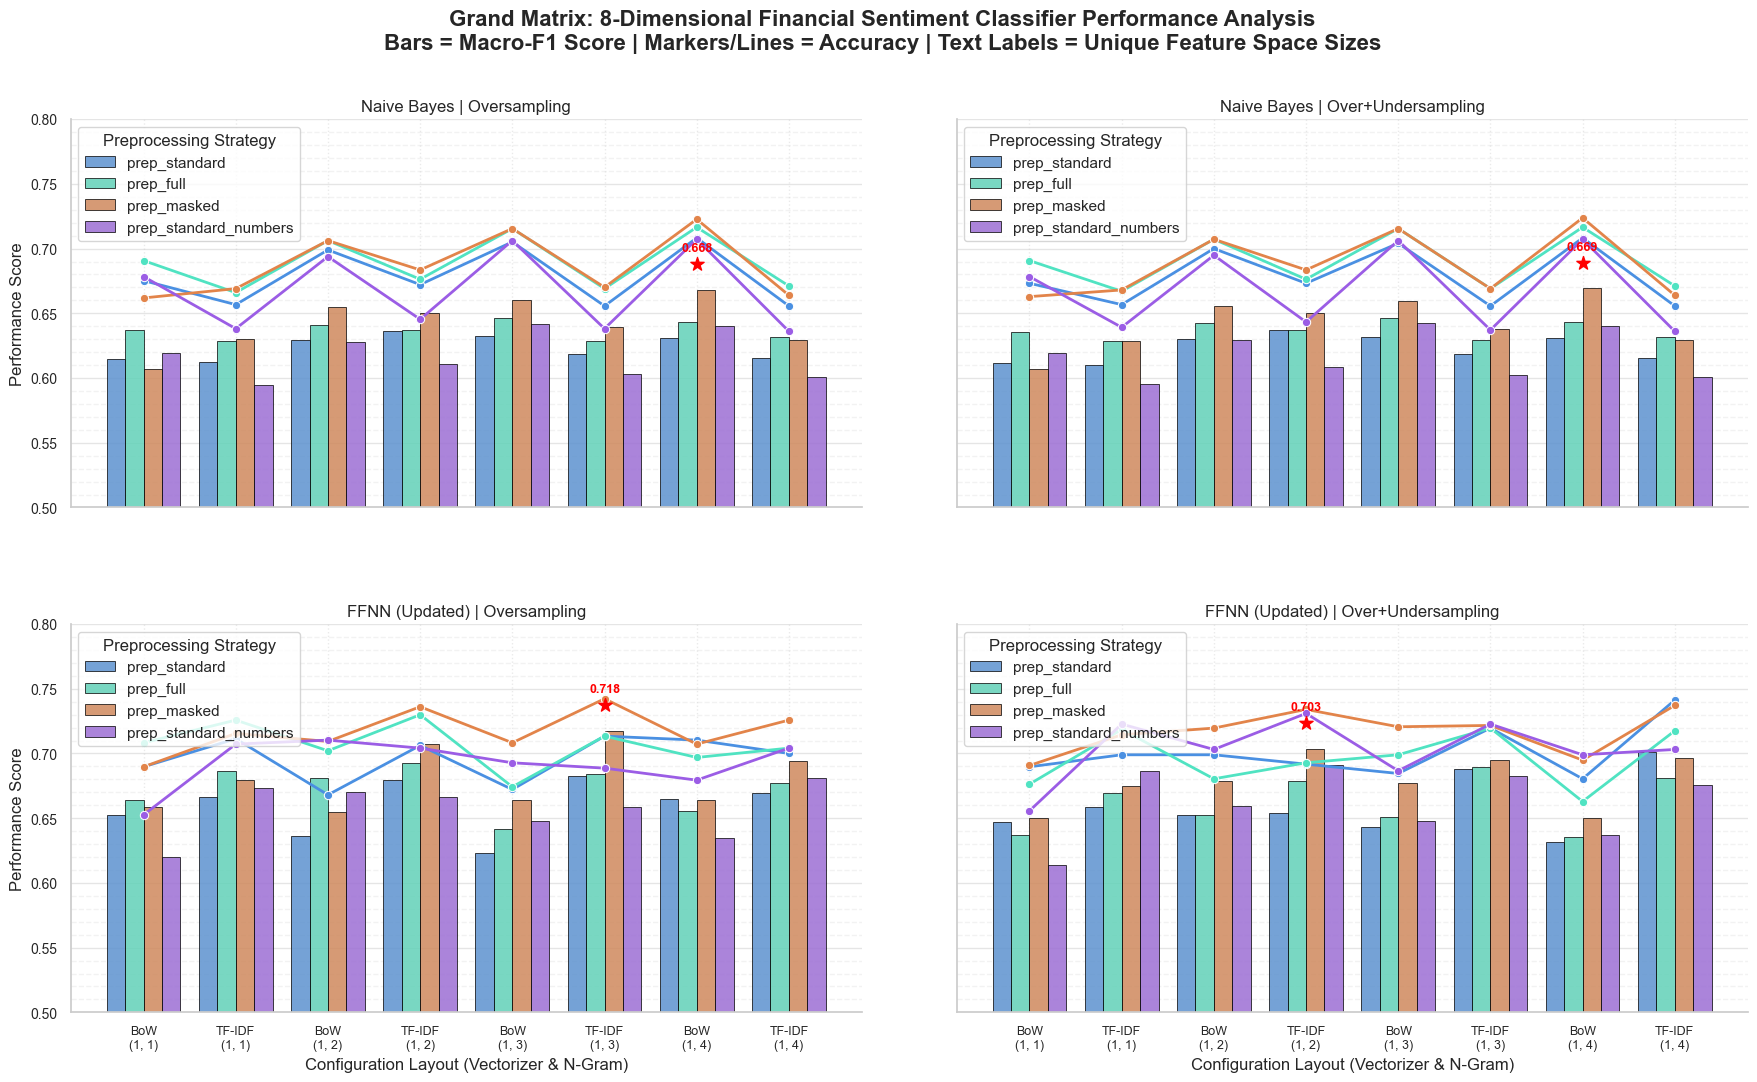

In [94]:
# ==========================================
# 5. ADVANCED MULTIDIMENSIONAL VISUALIZATION (8 DIMENSIONS)
# ==========================================
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

local_winners = results_df.loc[results_df.groupby(['Model', 'Sampling Strategy'])['Macro-F1'].idxmax()]

# 2. Identify Global Winner
global_winner = results_df.loc[results_df['Macro-F1'].idxmax()]

print("\n--- GLOBAL PERFORMANCE WINNER ---")
print(global_winner[['Model', 'Strategy', 'Sampling Strategy', 'Vectorizer', 'N-Gram', 'Macro-F1']])
print("-" * 35)

# Set high-quality styling for scientific reporting
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 10,
    'axes.labelsize': 12,
    'axes.titlesize': 12,
    'xtick.labelsize': 9,
    'ytick.labelsize': 10,
    'figure.titlesize': 16
})

# UPDATED: Extended to handle all 4 datasets with distinct hex codes
strategy_colors = {
    'prep_standard': '#4A90E2',          # Soft Blue
    'prep_full': '#50E3C2',              # Mint Green
    'prep_masked': '#E2844A',            # Muted Orange
    'prep_standard_numbers': '#9B5DE5'   # Vibrant Deep Purple
}
strategy_order = ['prep_standard', 'prep_full', 'prep_masked', 'prep_standard_numbers']

print("\nGenerating 8D publication-quality performance grid...")

# Prepare a combined label for X-axis to group Vectorizer + N-Gram cleanly
# This elegantly handles Dim 3 (N-Gram) and Dim 6 (Vectorizer) side-by-side
results_df["Vec_N-Gram"] = results_df["Vectorizer"] + "\n" + results_df["N-Gram"]

# Set dynamic boundaries to maximize visible differences
min_y = min(results_df["Macro-F1"].min(), results_df["Accuracy"].min())
max_y = max(results_df["Macro-F1"].max(), results_df["Accuracy"].max())
y_lower_bound = max(0.0, float(np.floor(min_y * 20) / 20) - 0.05)
y_upper_bound = min(1.0, float(np.ceil(max_y * 20) / 20) + 0.05)

# Initialize FactorPlot Grid
# Dim 1 (Model) -> Rows | Dim 2 (Sampling Strategy) -> Columns
g = sns.FacetGrid(
    data=results_df,
    row="Model",
    col="Sampling Strategy",
    height=5.5,  # Slightly expanded height to give the 4th bar breathing room
    aspect=1.6,
    sharex=True,
    sharey=True
)

# Function to draw the hybrid metrics + label feature sizes on each subplot
def draw_multidimensional_plots(data, **kwargs):
    ax = plt.gca()

    # 1. Plot Bars and Lines tracking all 4 pipeline variations
    sns.barplot(data=data, x="Vec_N-Gram", y="Macro-F1", hue="Strategy",
                hue_order=strategy_order, palette=strategy_colors,
                edgecolor="black", linewidth=0.6, alpha=0.85, ax=ax)

    sns.lineplot(data=data, x="Vec_N-Gram", y="Accuracy", hue="Strategy",
                 hue_order=strategy_order, palette=strategy_colors,
                 marker="o", markersize=6, linewidth=2, legend=False, ax=ax)

    # 2. Highlight Local Winner
    best_row = data.loc[data['Macro-F1'].idxmax()]

    # Draw a star highlight marker on the winner
    x_coords = data['Vec_N-Gram'].unique().tolist()
    x_idx = x_coords.index(best_row['Vec_N-Gram'])

    ax.scatter(x_idx, best_row['Macro-F1'] + 0.02, color='red', marker='*', s=100, zorder=5)

    # 3. Add Annotations
    ax.text(x_idx, best_row['Macro-F1'] + 0.03, f"{best_row['Macro-F1']:.3f}",
            ha='center', fontsize=9, color='red', weight='bold')

    # # Dim 7 (Feature Size Matrix Labels)
    # unique_feats = data.drop_duplicates(subset=["Vec_N-Gram"])
    # for idx, row_val in unique_feats.iterrows():
    #     x_pos = unique_feats['Vec_N-Gram'].tolist().index(row_val['Vec_N-Gram'])
    #     ax.text(x_pos, y_lower_bound + 0.01, f"Feat:\n{int(row_val['Feature Size'])}",
    #             ha='center', va='bottom', fontsize=7, color='#555555',
    #             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

# Map our custom drawing function across the FacetGrid matrix
g.map_dataframe(draw_multidimensional_plots)

# Refine grid architecture layouts
g.set_axis_labels("Configuration Layout (Vectorizer & N-Gram)", "Performance Score")
g.set_titles(row_template="{row_name}", col_template="{col_name}")

# Fine-tune tick formatting and grid visibility parameters
for ax in g.axes.flat:
    ax.set_ylim(y_lower_bound, y_upper_bound)

    # Setup precision tick lines to easily read subtle discrepancies
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.05))
    ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.01))
    ax.yaxis.grid(True, which='major', linestyle="-", alpha=0.5)
    ax.yaxis.grid(True, which='minor', linestyle="--", alpha=0.25)
    ax.xaxis.grid(True, linestyle=":", alpha=0.4)

    # Handle Legend cleanup to avoid duplicate entries across windows
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        # UPDATED: Sliced at [:4] instead of [:3] to ensure all 4 components display inside the legend
        ax.legend(handles[:4], labels[:4], title="Preprocessing Strategy", loc="upper left", frameon=True)

# Adjust overall margins clean for title placement
g.fig.subplots_adjust(top=0.88, hspace=0.3, wspace=0.12)
g.fig.suptitle(
    "Grand Matrix: 8-Dimensional Financial Sentiment Classifier Performance Analysis\n"
    "Bars = Macro-F1 Score | Markers/Lines = Accuracy | Text Labels = Unique Feature Space Sizes",
    weight="bold"
)

# Export structural matrix graphic asset
plt.savefig("grand_8d_evaluation_matrix.png", dpi=300, bbox_inches='tight')
print("Complete 8D Evaluation Grid tracking all 4 strategies saved as 'grand_8d_evaluation_matrix.png'!")
plt.show()


In [ ]:
# grafic data for latex

import numpy as np
import pandas as pd

# --- ASSUMING `results_df` IS ALREADY CONSTRUCTED IN YOUR PIPELINE ---
# Example Mock Setup to ensure code execution context aligns:
# results_df["Vec_N-Gram"] = results_df["Vectorizer"] + "_" + results_df["N-Gram"].str.replace(" ", "")

# Clean configurations for LaTeX compatibility (avoiding spaces in coordinates)
results_df["Vec_N_Gram_Label"] = (
    results_df["Vectorizer"] + " " + results_df["N-Gram"]
)

# Identify local winners for the LaTeX star markers
results_df["Is_Local_Winner"] = 0
for (model, sampling), group in results_df.groupby(
    ["Model", "Sampling Strategy"]
):
    idx_max = group["Macro-F1"].idxmax()
    results_df.loc[idx_max, "Is_Local_Winner"] = 1

# Select only the columns needed by pgfplots to keep file sizes lean
export_cols = [
    "Model",
    "Sampling Strategy",
    "Strategy",
    "Vec_N_Gram_Label",
    "Macro-F1",
    "Accuracy",
    "Is_Local_Winner",
]
latex_data = results_df[export_cols].copy()

# Save as a clean data file for LaTeX
latex_data.to_csv("plot_data.csv", index=False)
print("Data successfully optimized and exported to 'plot_data.csv' for pgfplots!")


Running targeted pipeline evaluations for multi-metric reporting...

================================ ADVANCED EVALUATION METRICS REPORT ================================
    Configuration              Strategy Accuracy Precision Recall Macro-F1
Naive Bayes + BoW         prep_standard   0.7072    0.6610 0.6223   0.6374
Naive Bayes + BoW             prep_full   0.7175    0.6722 0.6385   0.6519
Naive Bayes + BoW           prep_masked   0.7196    0.6711 0.6717   0.6681
Naive Bayes + BoW prep_standard_numbers   0.7062    0.6650 0.6259   0.6418
    FFNN + TF-IDF         prep_standard   0.7371    0.7146 0.7208   0.7163
    FFNN + TF-IDF             prep_full   0.7216    0.6713 0.7156   0.6886
    FFNN + TF-IDF           prep_masked   0.7340    0.7047 0.7197   0.7108
    FFNN + TF-IDF prep_standard_numbers   0.7258    0.6798 0.7006   0.6890


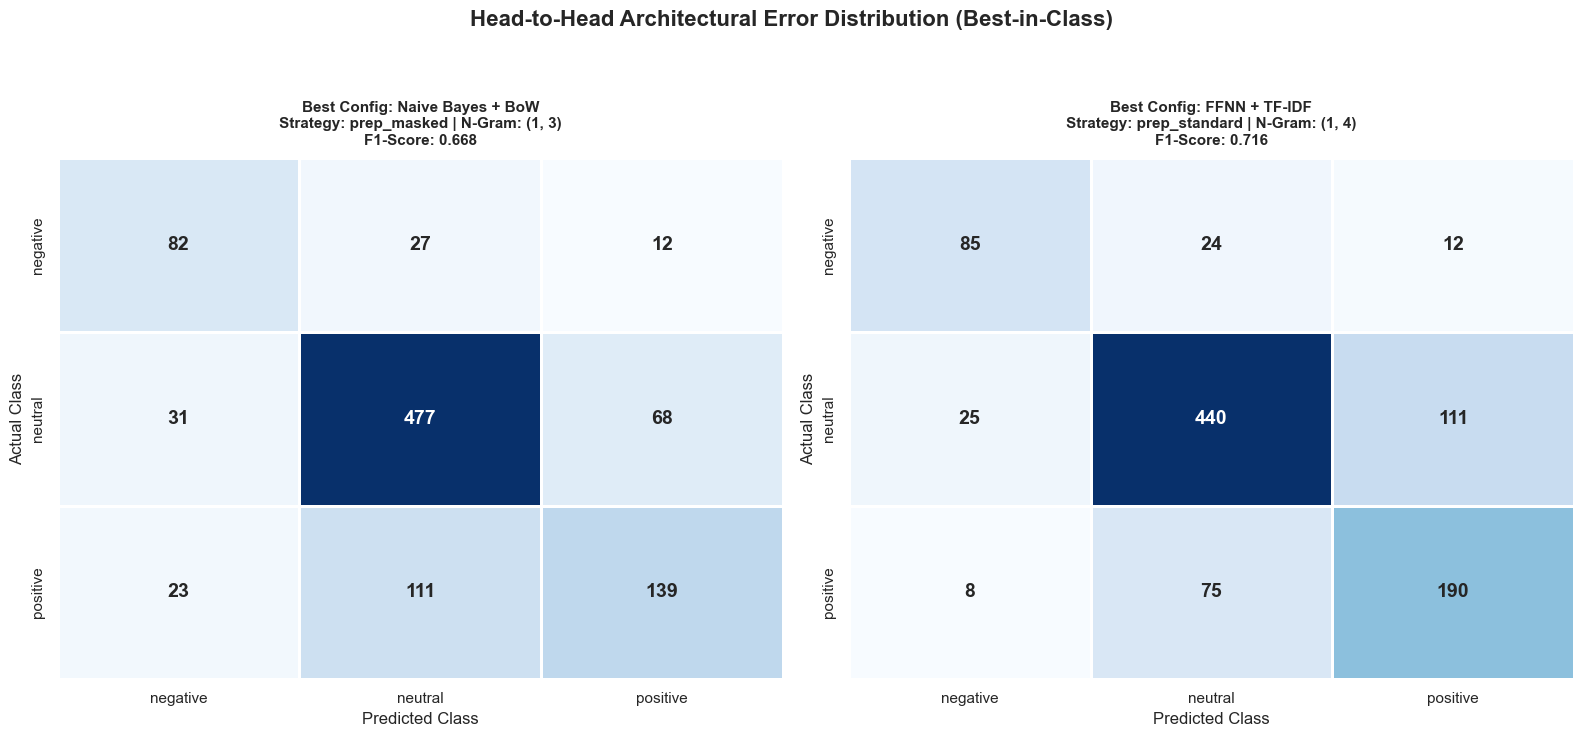

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.base import clone

# ==========================================
# 5. ADVANCED TARGETED HEAD-TO-HEAD REPORT
# ==========================================

# Define target configurations
target_configs = [
    {"Model Name": "Naive Bayes", "Model": models["Naive Bayes"], "Vectorizer": "BoW", "N-Gram": (1, 4)},
    {"Model Name": "FFNN", "Model": models["FFNN (Updated)"], "Vectorizer": "TF-IDF", "N-Gram": (1, 3)}
]

strategies = ["prep_standard", "prep_full", "prep_masked", "prep_standard_numbers"]
custom_token_pattern = r'(?u)\[?\b\w[-\w\.]*\b\]?'

detailed_results = []
confusion_matrices = {} # Stores matrices for visual reporting

print("Running targeted pipeline evaluations for multi-metric reporting...")

for config in target_configs:
    model_label = f"{config['Model Name']} + {config['Vectorizer']}"
    confusion_matrices[model_label] = {}

    for strategy in strategies:
        if strategy not in df.columns:
            continue

        # Clean and split data identically to main loop
        df_clean = df.dropna(subset=[strategy, TARGET_COL]).reset_index(drop=True)
        X_train_raw, X_test_raw, y_train, y_test = train_test_split(
            df_clean[strategy], df_clean[TARGET_COL],
            test_size=0.20, random_state=42, stratify=df_clean[TARGET_COL]
        )

        # Setup vectorizer based on configuration
        if config["Vectorizer"] == "BoW":
            vect = CountVectorizer(ngram_range=config["N-Gram"], token_pattern=custom_token_pattern)
        else:
            vect = TfidfVectorizer(ngram_range=config["N-Gram"], token_pattern=custom_token_pattern)

        X_train_vec = vect.fit_transform(X_train_raw)
        X_test_vec = vect.transform(X_test_raw)

        # Balance dataset using Oversampling (SMOTE) as requested
        sampler = clone(samplers["Oversampling"])
        X_train_res, y_train_res = sampler.fit_resample(X_train_vec, y_train)

        # Fit model clone
        clf = clone(config["Model"])
        clf.fit(X_train_res, y_train_res)
        y_pred = clf.predict(X_test_vec)

        # Calculate full suite of metrics
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
        rec = recall_score(y_test, y_pred, average='macro', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)

        # Save structural tracking information
        detailed_results.append({
            "Configuration": model_label,
            "Strategy": strategy,
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "Macro-F1": f1
        })

        # Save confusion matrix matrix array
        confusion_matrices[model_label][strategy] = {
            'matrix': confusion_matrix(y_test, y_pred),
            'f1': f1
        }

# Convert results into structured report format
report_df = pd.DataFrame(detailed_results)

print("\n" + "="*32 + " ADVANCED EVALUATION METRICS REPORT " + "="*32)
print(report_df.to_string(index=False, formatters={
    'Accuracy': '{:,.4f}'.format, 'Precision': '{:,.4f}'.format,
    'Recall': '{:,.4f}'.format, 'Macro-F1': '{:,.4f}'.format
}))
print("="*100)


# ==========================================
# 2. TARGETED BEST-PERFORMING CONFUSION MATRICES
# ==========================================
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 7))
class_labels = label_encoder.classes_

for idx, model_label in enumerate(["Naive Bayes + BoW", "FFNN + TF-IDF"]):
    ax = axes[idx]

    # 1. Logic to identify the BEST strategy for this model based on F1
    best_strategy = max(confusion_matrices[model_label],
                        key=lambda s: confusion_matrices[model_label][s]['f1'])
    best_cm = confusion_matrices[model_label][best_strategy]['matrix']
    best_f1 = confusion_matrices[model_label][best_strategy]['f1']

    # 2. Retrieve N-Gram dynamically from the target_configs list
    # Matches the configuration object based on the label structure
    ngram_val = target_configs[idx]["N-Gram"]

    # 3. Plotting the single best matrix for the model
    sns.heatmap(
        best_cm, annot=True, fmt="d", cmap="Blues", cbar=False,
        xticklabels=class_labels, yticklabels=class_labels,
        ax=ax, linewidths=1, linecolor='white',
        annot_kws={"size": 14, "weight": "bold"}
    )

    # 4. Updated Title to include the N-Gram range
    ax.set_title(
        f"Best Config: {model_label}\n"
        f"Strategy: {best_strategy} | N-Gram: {ngram_val}\n"
        f"F1-Score: {best_f1:.3f}",
        weight="bold", fontsize=11, pad=10
    )
    ax.set_xlabel("Predicted Class")
    ax.set_ylabel("Actual Class")

plt.suptitle("Head-to-Head Architectural Error Distribution (Best-in-Class)", weight="bold", fontsize=16, y=1.05)
plt.tight_layout()
plt.savefig("best_pipeline_confusion_matrices.png", dpi=300, bbox_inches='tight')
plt.show()



EXECUTING TARGETED MULTICLASS VS. BINARY COMPREHENSIVE ERROR ANALYSIS
Base Checks -> Multiclass Samples: 4846 | Binary Samples: 1967
----------------------------------------------------------------------

>>> Running Pipeline Evaluations for Task Domain: MULTICLASS <<<
 -> Naive Bayes: Test Accuracy = 0.7227 | Macro-F1 = 0.6680
 -> FFNN: Test Accuracy = 0.7412 | Macro-F1 = 0.7196

>>> Running Pipeline Evaluations for Task Domain: BINARY (NO NEUTRAL) <<<
 -> Naive Bayes: Test Accuracy = 0.8629 | Macro-F1 = 0.8382
 -> FFNN: Test Accuracy = 0.3071 | Macro-F1 = 0.2350


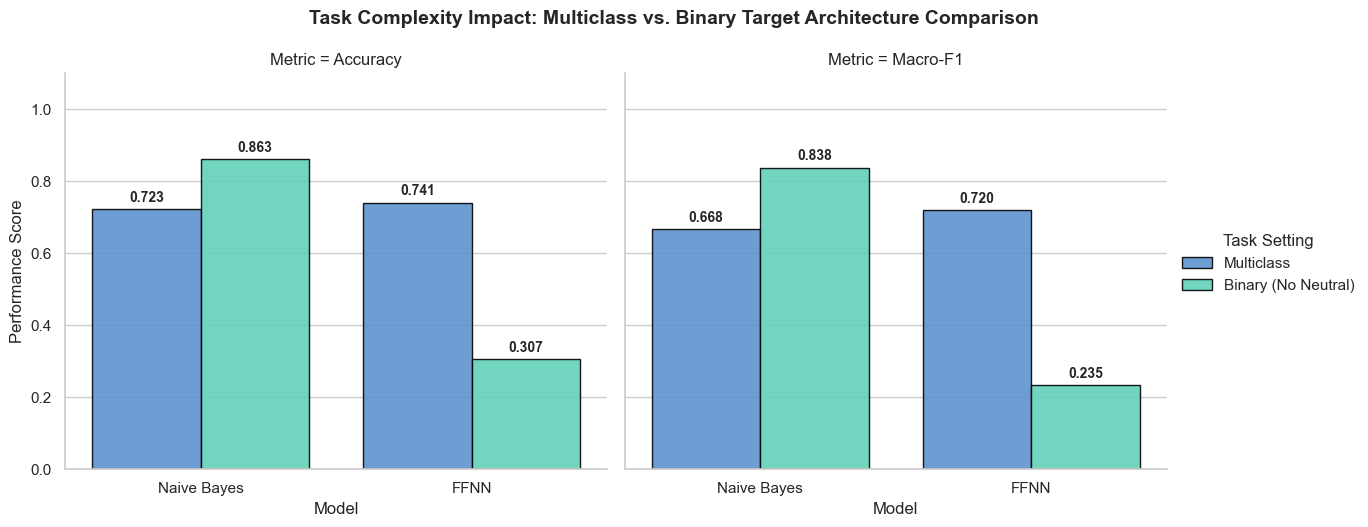


[+] Success: All evaluation errors exported to 'Misclassified_Samples_Log.csv'

#############################################
--- TARGETED SYSTEMATIC SAMPLE ERRORS ---
#############################################

=============== MULTICLASS ERRORS ===============

Pipeline: Naive Bayes (BoW | (1, 4))
True Label:      [POSITIVE]
Predicted Label: [NEUTRAL]
Raw Input:       In the Asia-Pacific region , Visa Wave is available in Malaysia , Taiwan and South Korea and will be expanded to Japan and Southeast Asia this year , Jung added .
Masked Tokens:   asia-pacific region visa wave available malaysia taiwan south korea expand japan southeast asia jung add
-----------------------------------------------------------------

Pipeline: FFNN (TF-IDF | (1, 3))
True Label:      [POSITIVE]
Predicted Label: [NEUTRAL]
Raw Input:       Basware Corporation stock exchange release August 31 , 2010 at 16:25 Basware signed a large deal with an international industrial group Basware will deliver Invoice Au

In [71]:
# ==========================================
# 6. ADVANCED ERROR ANALYSIS MODULE (PREP_MASKED ONLY: MULTICLASS VS. BINARY)
# ==========================================
print("\n" + "="*50)
print("EXECUTING TARGETED MULTICLASS VS. BINARY COMPREHENSIVE ERROR ANALYSIS")
print("="*50)

target_configs = [
    {"Model Name": "Naive Bayes", "Model": models["Naive Bayes"], "Vectorizer": "BoW", "N-Gram": (1, 4)},
    {"Model Name": "FFNN", "Model": models["FFNN (Updated)"], "Vectorizer": "TF-IDF", "N-Gram": (1, 3)}
]

STRATEGY = "prep_masked"
custom_token_pattern = r'(?u)\[?\b\w[-\w\.]*\b\]?'
all_errors = []
performance_metrics = [] # <-- Stores metrics for visual tracking

if STRATEGY in df.columns:
    # -------------------------------------------------------------
    # SETUP 1: MULTICLASS DATASET (Original)
    # -------------------------------------------------------------
    df_multi = df.dropna(subset=[STRATEGY, TARGET_COL]).reset_index(drop=False)

    # -------------------------------------------------------------
    # SETUP 2: BINARY DATASET (Remove Neutral)
    # -------------------------------------------------------------
    neutral_idx = list(label_encoder.classes_).index('neutral')
    df_binary = df_multi[df_multi[TARGET_COL] != neutral_idx].copy().reset_index(drop=False)

    tasks = {
        "Multiclass": df_multi,
        "Binary (No Neutral)": df_binary
    }

    print(f"Base Checks -> Multiclass Samples: {len(df_multi)} | Binary Samples: {len(df_binary)}")
    print("-" * 70)

    for task_name, target_df in tasks.items():
        print(f"\n>>> Running Pipeline Evaluations for Task Domain: {task_name.upper()} <<<")

        for config in target_configs:
            model_label = f"{config['Model Name']} ({config['Vectorizer']} | {config['N-Gram']})"

            X_train_raw, X_test_raw, y_train, y_test, _, idx_test = train_test_split(
                target_df[STRATEGY], target_df[TARGET_COL], target_df.index,
                test_size=0.20, random_state=42, stratify=target_df[TARGET_COL]
            )

            if config["Vectorizer"] == "BoW":
                vect = CountVectorizer(ngram_range=config["N-Gram"], token_pattern=custom_token_pattern)
            else:
                vect = TfidfVectorizer(ngram_range=config["N-Gram"], token_pattern=custom_token_pattern)

            X_train_vec = vect.fit_transform(X_train_raw)
            X_test_vec = vect.transform(X_test_raw)

            sampler = SMOTE(random_state=42)
            X_train_res, y_train_res = sampler.fit_resample(X_train_vec, y_train)

            clf = clone(config["Model"])
            clf.fit(X_train_res, y_train_res)
            y_pred = clf.predict(X_test_vec)

            acc = accuracy_score(y_test, y_pred)
            f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)

            print(f" -> {config['Model Name']}: Test Accuracy = {acc:.4f} | Macro-F1 = {f1:.4f}")

            # Append results for chart extraction
            performance_metrics.append({
                "Task Setting": task_name,
                "Model": config['Model Name'],
                "Accuracy": acc,
                "Macro-F1": f1
            })

            errors_mask = y_test != y_pred

            if np.any(errors_mask):
                error_indices = idx_test[errors_mask]
                true_labels_text = label_encoder.inverse_transform(target_df.loc[error_indices, TARGET_COL])
                pred_labels_text = label_encoder.inverse_transform(y_pred[errors_mask])

                errors_df = pd.DataFrame({
                    'Task_Setting': task_name,
                    'Pipeline_Configuration': model_label,
                    'Original_Sentence': target_df.loc[error_indices, 'sentence'].values,
                    'Preprocessed_Text': target_df.loc[error_indices, STRATEGY].values,
                    'True_Label': true_labels_text,
                    'Predicted_Label': pred_labels_text
                })
                all_errors.append(errors_df)

    # -------------------------------------------------------------
    # NEW: GENERATE COMPARISON GRAPHIC
    # -------------------------------------------------------------
    metrics_df = pd.DataFrame(performance_metrics)
    melted_metrics = metrics_df.melt(id_vars=["Task Setting", "Model"], var_name="Metric", value_name="Score")

    sns.set_theme(style="whitegrid")
    g = sns.catplot(
        data=melted_metrics,
        kind="bar",
        x="Model",
        y="Score",
        hue="Task Setting",
        col="Metric",
        palette={"Multiclass": "#4A90E2", "Binary (No Neutral)": "#50E3C2"},
        edgecolor="black",
        alpha=0.9,
        height=5,
        aspect=1.2
    )

    # Add numeric benchmarks on top of bars cleanly
    for ax in g.axes.flat:
        for container in ax.containers:
            ax.bar_label(container, fmt="%.3f", padding=3, fontsize=10, fontweight='bold')
        ax.set_ylim(0, 1.1)
        ax.set_ylabel("Performance Score")

    g.fig.suptitle("Task Complexity Impact: Multiclass vs. Binary Target Architecture Comparison", weight="bold", fontsize=14, y=1.05)
    plt.savefig("multiclass_vs_binary_comparison.png", dpi=300, bbox_inches='tight')
    plt.show()

    # -------------------------------------------------------------
    # EXPORT & DRILL-DOWN ANALYSIS REPORTING
    # -------------------------------------------------------------
    if all_errors:
        master_errors_df = pd.concat(all_errors, ignore_index=True)
        master_errors_df.to_csv("Misclassified_Samples_Log.csv", index=False, sep=";")
        print("\n" + "="*70)
        print("[+] Success: All evaluation errors exported to 'Misclassified_Samples_Log.csv'")
        print("="*70)

        print("\n" + "#"*45 + "\n--- TARGETED SYSTEMATIC SAMPLE ERRORS ---\n" + "#"*45)

        for setting in ["Multiclass", "Binary (No Neutral)"]:
            print(f"\n" + "="*15 + f" {setting.upper()} ERRORS " + "="*15)
            setting_subset = master_errors_df[master_errors_df['Task_Setting'] == setting]

            for model_lbl in setting_subset['Pipeline_Configuration'].unique():
                final_subset = setting_subset[setting_subset['Pipeline_Configuration'] == model_lbl]

                if not final_subset.empty:
                    row = final_subset.sample(1, random_state=42).iloc[0]
                    print(f"\nPipeline: {row['Pipeline_Configuration']}")
                    print(f"True Label:      [{row['True_Label'].upper()}]")
                    print(f"Predicted Label: [{row['Predicted_Label'].upper()}]")
                    print(f"Raw Input:       {row['Original_Sentence']}")
                    print(f"Masked Tokens:   {row['Preprocessed_Text']}")
                    print("-" * 65)
    else:
        print("\n[!] Outstanding performance! Zero classification errors caught across test splits.")
else:
    print(f"Configuration Error: Preprocessing column '{STRATEGY}' missing from the root dataframe structure.")



EXECUTING CROSS-PIPELINE VISUAL DISAGREEMENT ANALYSIS
[+] Found 102 cross-pipeline prediction contradictions.


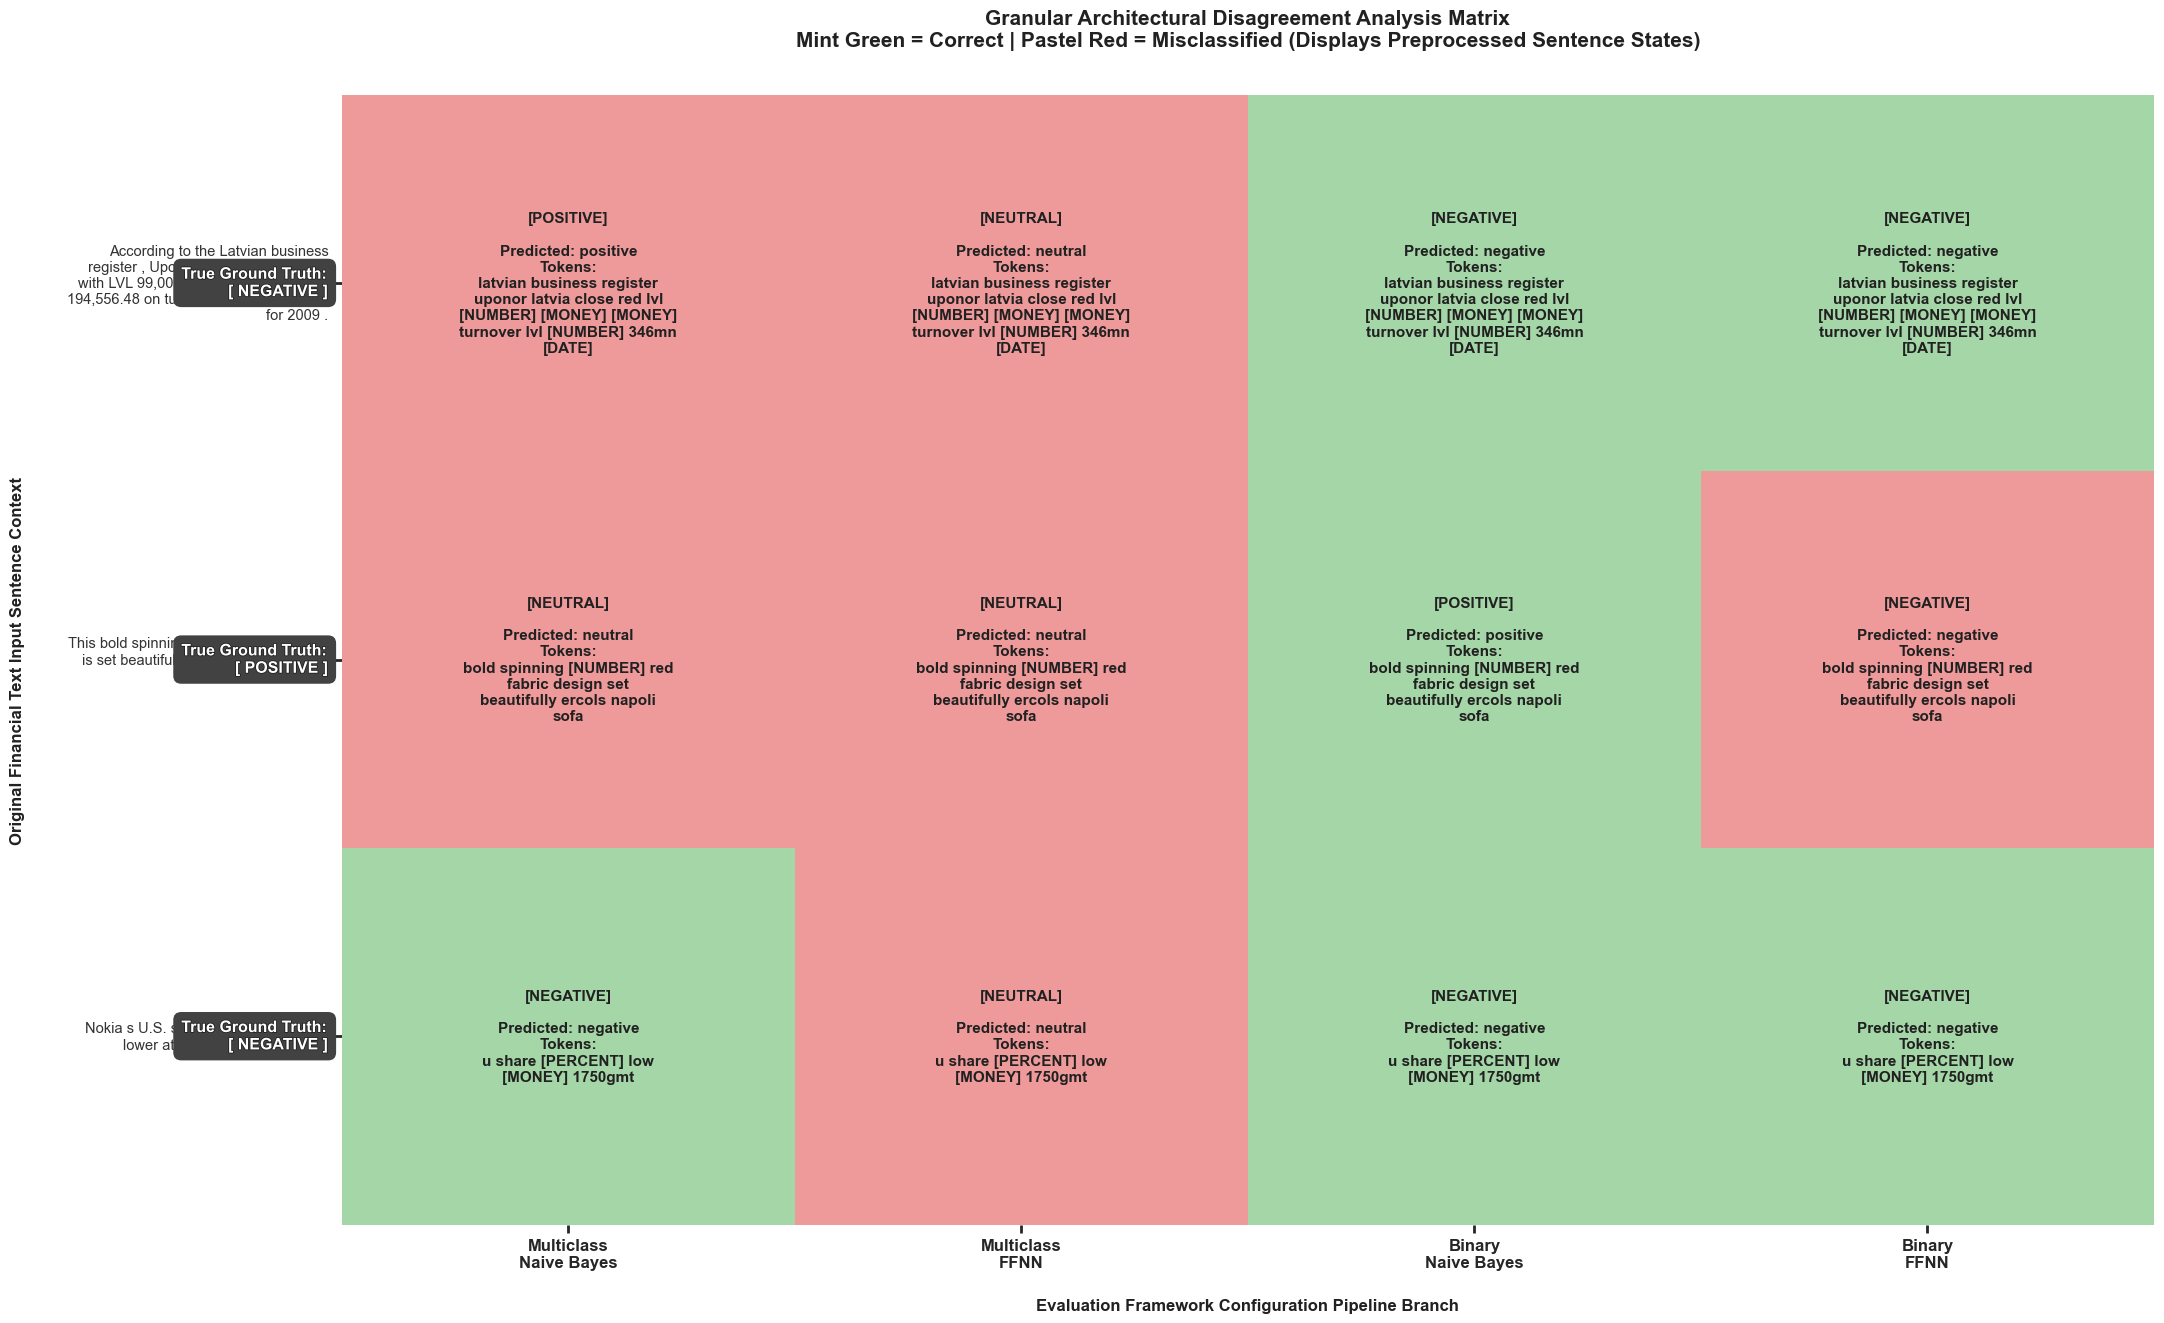

[+] Rendering fixed! Modernized matrix successfully saved as 'modernized_model_disagreement_matrix.png'


In [72]:
# ==========================================
# 6. ADVANCED CROSS-PIPELINE DISAGREEMENT & VISUALIZATION MODULE
# ==========================================
print("\n" + "="*50)
print("EXECUTING CROSS-PIPELINE VISUAL DISAGREEMENT ANALYSIS")
print("="*50)

target_configs = [
    {"Model Name": "Naive Bayes", "Model": models["Naive Bayes"], "Vectorizer": "BoW", "N-Gram": (1, 4)},
    {"Model Name": "FFNN", "Model": models["FFNN (Updated)"], "Vectorizer": "TF-IDF", "N-Gram": (1, 3)}
]

STRATEGY = "prep_masked"
custom_token_pattern = r'(?u)\[?\b\w[-\w\.]*\b\]?'

all_preds_list = []

if STRATEGY in df.columns:
    df_multi = df.dropna(subset=[STRATEGY, TARGET_COL]).reset_index(drop=False)
    neutral_idx = list(label_encoder.classes_).index('neutral')
    df_binary = df_multi[df_multi[TARGET_COL] != neutral_idx].copy().reset_index(drop=False)

    tasks = {"Multiclass": df_multi, "Binary": df_binary}

    for task_name, target_df in tasks.items():
        for config in target_configs:
            model_label = f"{task_name}\n{config['Model Name']}"

            X_train_raw, X_test_raw, y_train, y_test, _, idx_test = train_test_split(
                target_df[STRATEGY], target_df[TARGET_COL], target_df.index,
                test_size=0.20, random_state=42, stratify=target_df[TARGET_COL]
            )

            if config["Vectorizer"] == "BoW":
                vect = CountVectorizer(ngram_range=config["N-Gram"], token_pattern=custom_token_pattern)
            else:
                vect = TfidfVectorizer(ngram_range=config["N-Gram"], token_pattern=custom_token_pattern)

            X_train_vec = vect.fit_transform(X_train_raw)
            X_test_vec = vect.transform(X_test_raw)

            sampler = SMOTE(random_state=42)
            X_train_res, y_train_res = sampler.fit_resample(X_train_vec, y_train)

            clf = clone(config["Model"])
            clf.fit(X_train_res, y_train_res)
            y_pred = clf.predict(X_test_vec)

            true_labels = label_encoder.inverse_transform(y_test)
            pred_labels = label_encoder.inverse_transform(y_pred)
            raw_sentences = target_df.loc[idx_test, 'sentence'].values
            masked_sentences = target_df.loc[idx_test, STRATEGY].values  # Extract preprocessed text strings

            for src_text, mask_text, true_lbl, pred_lbl in zip(raw_sentences, masked_sentences, true_labels, pred_labels):
                all_preds_list.append({
                    'Sentence': src_text,
                    'Masked_Sentence': mask_text,
                    'True Label': true_lbl,
                    'Pipeline': model_label,
                    'Prediction': pred_lbl
                })

    # -------------------------------------------------------------
    # 2. IDENTIFY AND FILTER DISAGREEMENTS
    # -------------------------------------------------------------
    preds_df = pd.DataFrame(all_preds_list)

    # Pivot predictions and tokens independently to avoid structural data loss
    pivot_pred = preds_df.pivot(index=['Sentence', 'True Label'], columns='Pipeline', values='Prediction').reset_index()
    pivot_mask = preds_df.pivot(index=['Sentence', 'True Label'], columns='Pipeline', values='Masked_Sentence').reset_index()

    disagreement_mask = (
        (pivot_pred['Multiclass\nNaive Bayes'] != pivot_pred['Multiclass\nFFNN']) |
        (pivot_pred['Binary\nNaive Bayes'] != pivot_pred['Binary\nFFNN']) |
        (pivot_pred['Multiclass\nFFNN'] != pivot_pred['Binary\nFFNN'])
    )

    disagreements_pred = pivot_pred[disagreement_mask].dropna().reset_index(drop=True)
    disagreements_mask_text = pivot_mask[disagreement_mask].dropna().reset_index(drop=True)

    print(f"[+] Found {len(disagreements_pred)} cross-pipeline prediction contradictions.")

    if not disagreements_pred.empty:
        # Sample structured rows uniformly using a fixed state seed
        sample_idx = disagreements_pred.sample(min(3, len(disagreements_pred)), random_state=15).index
        viz_sample_pred = disagreements_pred.loc[sample_idx].copy()
        viz_sample_mask = disagreements_mask_text.loc[sample_idx].copy()

        import textwrap
        viz_sample_pred['Short_Sentence'] = viz_sample_pred['Sentence'].apply(lambda x: "\n".join(textwrap.wrap(x, width=40)))
        viz_sample_mask['Short_Sentence'] = viz_sample_pred['Short_Sentence'] # Match coordinates

        pipeline_cols = ['Multiclass\nNaive Bayes', 'Multiclass\nFFNN', 'Binary\nNaive Bayes', 'Binary\nFFNN']

       # -------------------------------------------------------------
        # 3. BUILD MATRIX VALUES AND HIT MATCH MAPS (CORRECTED)
        # -------------------------------------------------------------
        color_grid = np.zeros((len(viz_sample_pred), len(pipeline_cols)))
        label_annotations = np.empty((len(viz_sample_pred), len(pipeline_cols)), dtype=object)

        for row_idx, (_, row) in enumerate(viz_sample_pred.iterrows()):
            true_label = row['True Label']
            mask_row = viz_sample_mask.iloc[row_idx]

            for col_idx, col_name in enumerate(pipeline_cols):
                pred_val = row[col_name]
                raw_mask_text = mask_row[col_name]

                # Clean text wrapping without the broken LaTeX code
                wrapped_mask = "\n".join(textwrap.wrap(str(raw_mask_text), width=28))

                # We format the string cleanly; bolding is handled globally by annot_kws below
                label_annotations[row_idx, col_idx] = f"[{pred_val.upper()}]\n\nPredicted: {pred_val}\nTokens:\n{wrapped_mask}"

                # Accuracy Evaluation: 1 = Correct (Green), 0 = Misclassified (Red)
                color_grid[row_idx, col_idx] = 1 if pred_val == true_label else 0

        # -------------------------------------------------------------
        # 4. HIGH-RESOLUTION MATPLOTLIB RENDER (CORRECTED)
        # -------------------------------------------------------------
        import seaborn as sns
        import matplotlib.pyplot as plt
        from matplotlib.colors import ListedColormap
        import matplotlib.patheffects as path_effects

        sns.set_theme(style="whitegrid")

        cell_height_inch = 3.8
        cell_width_inch = 4.2
        fig_width = len(pipeline_cols) * cell_width_inch + 5
        fig_height = len(viz_sample_pred) * cell_height_inch + 2
        fig, ax = plt.subplots(figsize=(fig_width, fig_height))

        # Modern palette: Index 0 = Pastel Red, Index 1 = Mint Green
        evaluation_cmap = ListedColormap(['#EF9A9A', '#A5D6A7'])

        sns.heatmap(
            color_grid,
            annot=label_annotations,
            fmt="",
            cmap=evaluation_cmap,
            cbar=False,
            linewidths=0,
            annot_kws={
                "size": 11,           # Bumped size slightly for the entire block
                "fontweight": "bold", # Focuses bold attention straight onto the [PREDICTION] tag
                "color": "#212121",
                "multialignment": "center"
            },
            ax=ax
        )

        ax.set_xticklabels(pipeline_cols, fontsize=12, fontweight='bold')
        ax.set_yticklabels(
            viz_sample_pred['Short_Sentence'].values,
            rotation=0,
            fontsize=10.5,
            va='center',
            ha='right',
            color='#333333'
        )

        ax.tick_params(axis='x', which='both', bottom=True, width=2)
        ax.tick_params(axis='y', which='both', left=True, width=2)

        # Fix the Ground Truth dark badges to use safe formatting too
        for idx, (_, row) in enumerate(viz_sample_pred.iterrows()):
            ax_text = ax.text(
                -0.03,
                idx + 0.5,
                f"True Ground Truth:\n[ {row['True Label'].upper()} ]",
                ha='right',
                va='center',
                fontsize=11.5,
                color='#FFFFFF',
                weight='bold',
                bbox=dict(facecolor='#424242', alpha=1.0, edgecolor='none', boxstyle='round,pad=0.5', zorder=5)
            )
            ax_text.set_path_effects([path_effects.withStroke(linewidth=1.2, foreground='#212121')])

        plt.title(
            "Granular Architectural Disagreement Analysis Matrix\nMint Green = Correct | Pastel Red = Misclassified (Displays Preprocessed Sentence States)",
            fontsize=15,
            weight='bold',
            pad=35,
            color='#212121'
        )
        plt.xlabel("Evaluation Framework Configuration Pipeline Branch", fontsize=12, weight='bold', labelpad=20, color='#212121')
        plt.ylabel("Original Financial Text Input Sentence Context", fontsize=12, weight='bold', labelpad=30, color='#212121')

        plt.tight_layout()
        plt.savefig("modernized_model_disagreement_matrix.png", dpi=300, bbox_inches='tight')
        plt.show()

        print("[+] Rendering fixed! Modernized matrix successfully saved as 'modernized_model_disagreement_matrix.png'")


In [ ]:
# ==========================================
# 6. MULTICLASS EXCLUSIVE DISAGREEMENT & VISUALIZATION MODULE (4 EXAMPLES + SHORT SENTENCES + LATEX)
# ==========================================
print("\n" + "="*50)
print("EXECUTING MULTICLASS MODEL DISAGREEMENT ANALYSIS (4 EXAMPLES, <50 CHARS)")
print("="*50)

# --- Farbdefinitionen (nur für Symbole) ---
correct_color = "#2E8B57"  # Dunkleres Grün für ✅
incorrect_color = "#CD5C5C"  # Dunkleres Rot für ❌

target_configs = [
    {"Model Name": "Naive Bayes", "Model": models["Naive Bayes"], "Vectorizer": "BoW", "N-Gram": (1, 4)},
    {"Model Name": "FFNN", "Model": models["FFNN (Updated)"], "Vectorizer": "TF-IDF", "N-Gram": (1, 3)}
]

STRATEGY = "prep_masked"
custom_token_pattern = r'(?u)\[?\b\w[-\w\.]*\b\]?'
all_preds_list = []

if STRATEGY in df.columns:
    df_multi = df.dropna(subset=[STRATEGY, TARGET_COL]).reset_index(drop=False)
    print(f"Total Multiclass Dataset Samples: {len(df_multi)}")
    print("-" * 70)

    # --- Modellvorhersagen berechnen ---
    for config in target_configs:
        model_label = config['Model Name']
        X_train_raw, X_test_raw, y_train, y_test, _, idx_test = train_test_split(
            df_multi[STRATEGY], df_multi[TARGET_COL], df_multi.index,
            test_size=0.20, random_state=42, stratify=df_multi[TARGET_COL]
        )
        vect = CountVectorizer(ngram_range=config["N-Gram"], token_pattern=custom_token_pattern) if config["Vectorizer"] == "BoW" else TfidfVectorizer(ngram_range=config["N-Gram"], token_pattern=custom_token_pattern)
        X_train_vec = vect.fit_transform(X_train_raw)
        X_test_vec = vect.transform(X_test_raw)
        sampler = SMOTE(random_state=42)
        X_train_res, y_train_res = sampler.fit_resample(X_train_vec, y_train)
        clf = clone(config["Model"])
        clf.fit(X_train_res, y_train_res)
        y_pred = clf.predict(X_test_vec)
        true_labels = label_encoder.inverse_transform(y_test)
        pred_labels = label_encoder.inverse_transform(y_pred)
        raw_sentences = df_multi.loc[idx_test, 'sentence'].values
        masked_sentences = df_multi.loc[idx_test, STRATEGY].values
        for src_text, mask_text, true_lbl, pred_lbl in zip(raw_sentences, masked_sentences, true_labels, pred_labels):
            all_preds_list.append({
                'Sentence': src_text,
                'Masked_Sentence': mask_text,
                'True Label': true_lbl,
                'Pipeline': model_label,
                'Prediction': pred_lbl
            })

    # --- Archetypen extrahieren ---
    preds_df = pd.DataFrame(all_preds_list)
    sentence_info = preds_df.drop_duplicates('Sentence')[['Sentence', 'True Label', 'Masked_Sentence']]
    p_pred = preds_df.pivot(index='Sentence', columns='Pipeline', values='Prediction').reset_index()
    p_pred = p_pred.merge(sentence_info, on='Sentence', how='left')
    p_pred = p_pred[p_pred['Sentence'].str.len() < 50].copy()

    # --- 4 spezifische Beispiele auswählen ---
    selected_rows = []

    # Archetyp 1: FFNN korrekt, Bayes falsch
    cond_1 = (p_pred['FFNN'] == p_pred['True Label']) & (p_pred['Naive Bayes'] != p_pred['True Label'])
    if cond_1.any():
        row = p_pred[cond_1].iloc[0].copy()
        row['Archetype'] = '1: FFNN Correct, NB Wrong'
        selected_rows.append(row)

    # Archetyp 2: FFNN falsch, Bayes korrekt
    cond_2 = (p_pred['FFNN'] != p_pred['True Label']) & (p_pred['Naive Bayes'] == p_pred['True Label'])
    if cond_2.any():
        row = p_pred[cond_2].iloc[0].copy()
        row['Archetype'] = '2: FFNN Wrong, NB Correct'
        selected_rows.append(row)

    # Archetyp 3: FFNN korrekt, Bayes falsch (2. Beispiel)
    if cond_1.sum() > 1:
        row = p_pred[cond_1].iloc[1].copy()
        row['Archetype'] = '3: FFNN Correct, NB Wrong (Alt)'
        selected_rows.append(row)
    elif cond_1.any():
        row = p_pred[cond_1].iloc[0].copy()
        row['Archetype'] = '3: FFNN Correct, NB Wrong (Alt)'
        selected_rows.append(row)

    # Archetyp 4: Beide falsch
    cond_4 = (p_pred['FFNN'] != p_pred['True Label']) & (p_pred['Naive Bayes'] != p_pred['True Label'])
    if cond_4.any():
        row = p_pred[cond_4].iloc[0].copy()
        row['Archetype'] = '4: Both Wrong'
        selected_rows.append(row)

    # --- Daten für die Tabelle vorbereiten ---
    viz_sample_pred = pd.DataFrame(selected_rows).reset_index(drop=True)
    display_df = viz_sample_pred.copy()

    # Kennzeichnung ohne Symbole
    for model in ['FFNN', 'Naive Bayes']:
        display_df[model] = display_df.apply(
            lambda row: f"{row[model]}" if row[model] == row['True Label'] else f"{row[model]}",
            axis=1
        )

    display_df['Sentence'] = display_df.apply(
        lambda row: f"\"{row['Sentence']}\" \\\\ \\textit{{\"Masked: {row['Masked_Sentence']}\"}}",
        axis=1
    )
    display_df['True Label'] = display_df['True Label'].str.upper()

    # --- LaTeX-Tabelle generieren ---
    latex_code = r"""\begin{table}[h]
\centering
\begin{tabular}{|p{8cm}|p{2cm}|p{2cm}|p{2cm}|}
\hline
\textbf{Sentence} & \textbf{True Label} & \textbf{FFNN Prediction} & \textbf{Naive Bayes Pred.}  \\ \hline
"""

    for _, row in display_df.iterrows():
        latex_code += f"{row['Sentence']} & {row['True Label'].lower()} & {row['FFNN']} & {row['Naive Bayes']}  \\\\ \\hline\n"

    latex_code += r"""\end{tabular}
\end{table}"""

    print("\n--- Clean LaTeX Code ---\n")
    print(latex_code)



EXECUTING MULTICLASS MODEL DISAGREEMENT ANALYSIS (4 EXAMPLES, <50 CHARS)
Total Multiclass Dataset Samples: 4846
----------------------------------------------------------------------

--- Clean LaTeX Code ---

\begin{table}[h]
\centering
\begin{tabular}{|p{7cm}|p{2cm}|p{2cm}|p{2cm}}
\hline
\textbf{Sentence} & \textbf{True Label} & \textbf{FFNN Prediction} & \textbf{Naive Bayes Pred.}  \\ \hline
"EUR 152.4 mn of this was net interest income ." \\ \textit{"Masked: [MONEY] net interest income"} & neutral & neutral & positive  \\ \hline
"`` I warmly welcome Michael Frei to Outotec ." \\ \textit{"Masked: warmly welcome michael frei outotec"} & positive & neutral & positive  \\ \hline
"Net profit was 35.5 mln compared with 29.8 mln ." \\ \textit{"Masked: net profit [NUMBER] 5mn compare [NUMBER] 8mn"} & positive & positive & negative  \\ \hline
"A 2001 agreement expired earlier this month ." \\ \textit{"Masked: [DATE] agreement expire earlier month"} & neutral & positive & positive  \\ \hlin